# Estimating the value of β and γ

$$\beta = \text{effective transmission rate per day}$$
$$\gamma = \text{recovery/removal rate per day}$$


Estimating β and γ from real COVID-19 data requires more than manually choosing values; this is essentially an inverse problem: you observe epidemic data and infer the SIR parameters that best reproduce those observations.

For the standard SIR model for COVID-19,

$$ \frac{dS}{dt}=-\beta\frac{SI}{N} $$ $$ \frac{dI}{dt}=\beta\frac{SI}{N}-\gamma I $$ $$ \frac{dR}{dt}=\gamma I $$

where β is the transmission rate, and γ is the recovery/removal rate Pant et al. (2026) [^1]. For estimating constant β and γ, ideally the dataset should contain: Date, Confirmed, Active infected, Recovered and Total population. This is extremely important because β, γ, and the initial conditions can interact during optimization.

In fact, identifiability studies show that estimating epidemic parameters becomes difficult when important states or parameters are not adequately observed.
Tuncer, N., & Le, T. T. (2018) [^2].

In this section, we will estimate β and γ by implementing the RK4 method with the help of the COVID-19 Dataset for Bangladesh from Kaggle. 


ESTIMATED SIR PARAMETERS
Country        : Bangladesh
Population N   : 164,689,383
Start date     : 2020-03-08
End date       : 2020-07-27
beta           : 0.1715094807
gamma          : 0.0942542420
R0 = beta/gamma: 1.8196473406


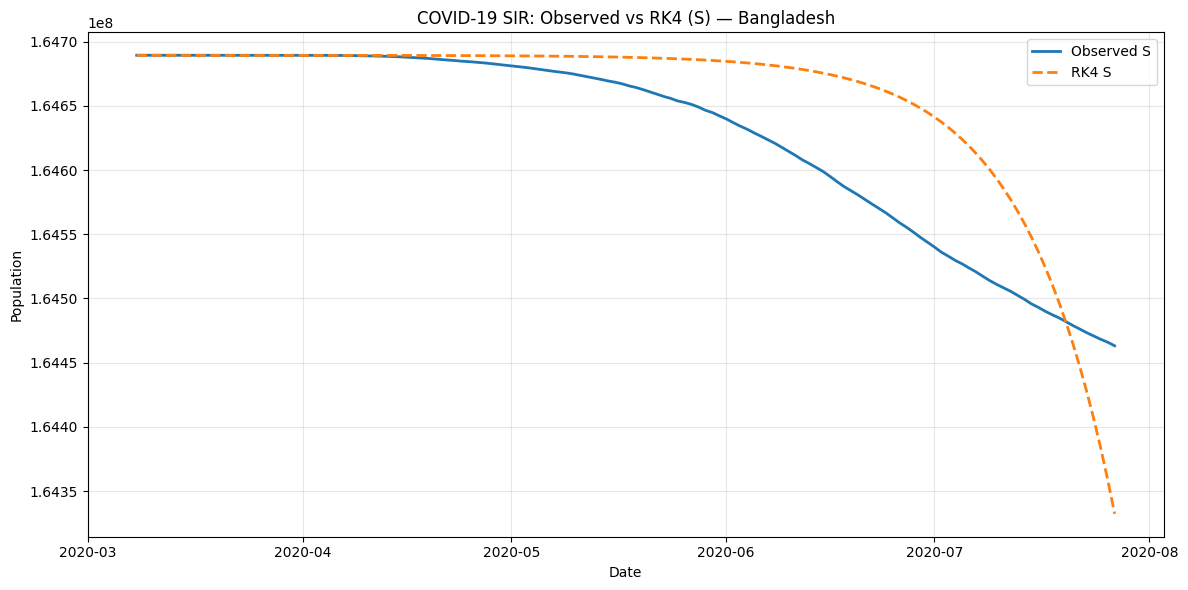

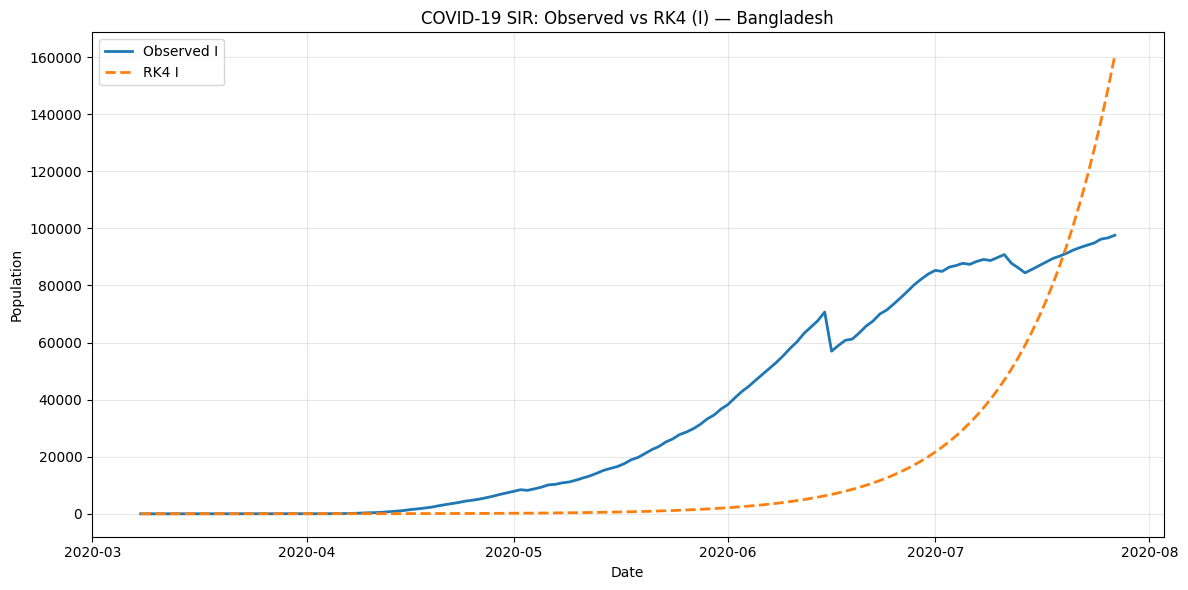

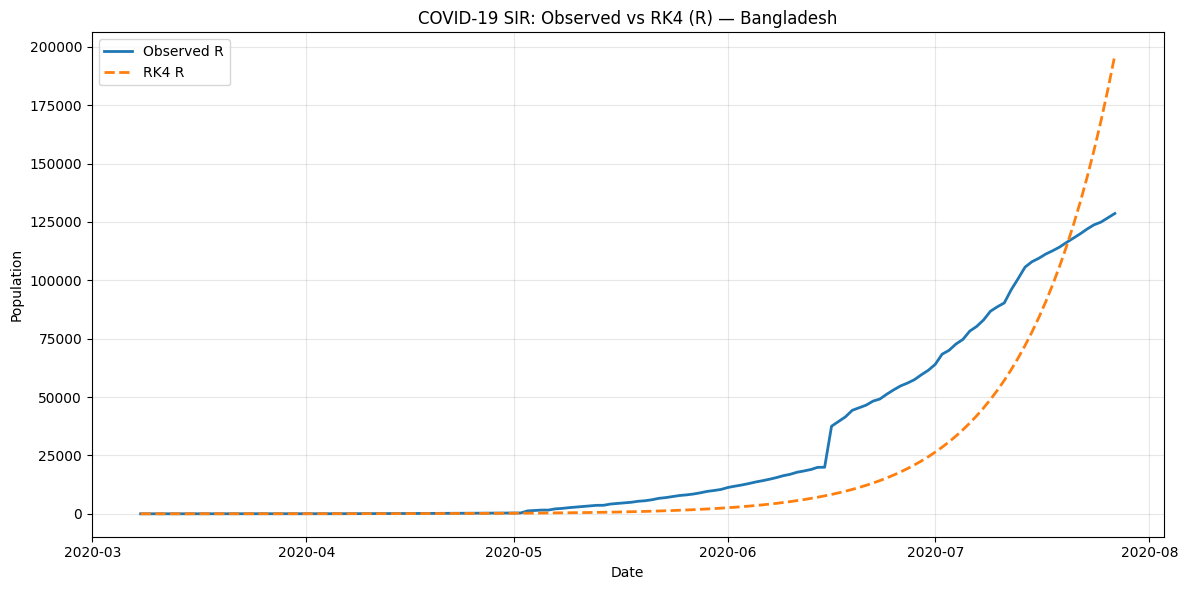


MODEL PERFORMANCE
Compartment           MAE                  MSE          RMSE       R2
          S 34,521.622536 2,550,213,550.984175 50,499.639117 0.522849
          I 22,818.473300 1,050,476,888.634334 32,411.061208 0.168832
          R 11,727.681623   375,884,687.230241 19,387.745801 0.756780

First 10 RK4 results:
      Date        S_RK4    I_RK4    R_RK4
2020-03-08 1.646894e+08 3.000000 0.000000
2020-03-09 1.646894e+08 3.240953 0.293972
2020-03-10 1.646894e+08 3.501259 0.611555
2020-03-11 1.646894e+08 3.782473 0.954646
2020-03-12 1.646894e+08 4.086272 1.325292
2020-03-13 1.646894e+08 4.414473 1.725709
2020-03-14 1.646894e+08 4.769033 2.158286
2020-03-15 1.646894e+08 5.152071 2.625606
2020-03-16 1.646894e+08 5.565874 3.130461
2020-03-17 1.646894e+08 6.012912 3.675864

FILES CREATED
CSV     : /kaggle/working/bangladesh_sir_rk4_results.csv
Excel   : /kaggle/working/bangladesh_sir_rk4_results.xlsx
Metrics : /kaggle/working/bangladesh_sir_metrics.csv
S plot  : /kaggle/working/banglad

In [1]:
import pandas as pd
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# COVID-19 SIR MODEL
# Parameter estimation + classical RK4 solution + metrics
# ============================================================

# ------------------------- CONFIG ----------------------------
INPUT_FILE = "/kaggle/input/datasets/abushayid/covid19/covid_19_clean_complete.csv"
COUNTRY = "Bangladesh"

# IMPORTANT:
# Use the actual total population of the selected country.
# This value is the 2020 population used for the Bangladesh example.
N = 164_689_383

OUTPUT_DIR = Path("/kaggle/working/")

CSV_FILE = OUTPUT_DIR / f"{COUNTRY.lower()}_sir_rk4_results.csv"
EXCEL_FILE = OUTPUT_DIR / f"{COUNTRY.lower()}_sir_rk4_results.xlsx"
METRICS_FILE = OUTPUT_DIR / f"{COUNTRY.lower()}_sir_metrics.csv"

PLOT_S = OUTPUT_DIR / f"{COUNTRY.lower()}_sir_S_observed_vs_rk4.png"
PLOT_I = OUTPUT_DIR / f"{COUNTRY.lower()}_sir_I_observed_vs_rk4.png"
PLOT_R = OUTPUT_DIR / f"{COUNTRY.lower()}_sir_R_observed_vs_rk4.png"


# ============================================================
# 1. READ COVID-19 DATA
# ============================================================
df = pd.read_csv(INPUT_FILE)

required_columns = [
    "Country/Region", "Date", "Confirmed",
    "Deaths", "Recovered", "Active"
]

missing = [c for c in required_columns if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df["Date"] = pd.to_datetime(df["Date"])

data = df[df["Country/Region"].eq(COUNTRY)].copy()

if data.empty:
    raise ValueError(
        f"No data found for '{COUNTRY}'. "
        f"Check the COUNTRY variable."
    )

# If the country has province/state rows, aggregate them by date.
data = (
    data.groupby("Date", as_index=False)
    [["Confirmed", "Deaths", "Recovered", "Active"]]
    .sum()
    .sort_values("Date")
    .reset_index(drop=True)
)

# ============================================================
# Construct observed S, I, R
# ============================================================
# Active = I
# Recovered + Deaths = R (removed)
# S = N - I - R
#
# Note: deaths are included in R because classical SIR has
# a single removed compartment.
data["I_obs"] = data["Active"].astype(float)
data["R_obs"] = (
    data["Recovered"].astype(float)
    + data["Deaths"].astype(float)
)
data["S_obs"] = N - data["I_obs"] - data["R_obs"]

if (data["S_obs"] < 0).any():
    raise ValueError(
        "Some S_obs values are negative. "
        "Increase/correct N for the selected country."
    )

# The dataset begins with zero active infections.
# Start estimation at the first day with I > 0.
positive_indices = np.flatnonzero(
    data["I_obs"].to_numpy() > 0
)

if len(positive_indices) == 0:
    raise ValueError("No positive Active-infection observations found.")

start_idx = int(positive_indices[0])

fit_data = data.iloc[start_idx:].copy().reset_index(drop=True)

S_obs = fit_data["S_obs"].to_numpy(dtype=float)
I_obs = fit_data["I_obs"].to_numpy(dtype=float)
R_obs = fit_data["R_obs"].to_numpy(dtype=float)

t = np.arange(len(fit_data), dtype=float)

# Initial SIR state
y0 = np.array(
    [S_obs[0], I_obs[0], R_obs[0]],
    dtype=float
)

# ============================================================
# 2. ESTIMATE beta AND gamma
# ============================================================

def sir_rhs(y, beta, gamma, population):
    """
    Normalized SIR equations:
        dS/dt = -beta*S*I/N
        dI/dt =  beta*S*I/N - gamma*I
        dR/dt =  gamma*I
    """
    S, I, R = y

    dS = -beta * S * I / population
    dI = beta * S * I / population - gamma * I
    dR = gamma * I

    return np.array([dS, dI, dR], dtype=float)


def simulate_for_estimation(beta, gamma):
    """
    Numerically integrate SIR during parameter fitting.
    solve_ivp is used only for parameter estimation.
    The final reported solution is produced independently
    with classical RK4 below.
    """
    solution = solve_ivp(
        lambda time, state: sir_rhs(
            state, beta, gamma, N
        ),
        [t[0], t[-1]],
        y0,
        t_eval=t,
        method="RK45",
        rtol=1e-7,
        atol=1e-2
    )

    if not solution.success:
        raise RuntimeError(solution.message)

    return solution.y


observed = np.vstack([S_obs, I_obs, R_obs])

# Normalize residuals so the very large S compartment does not
# completely dominate I and R during optimization.
scales = np.array([
    max(N, 1.0),
    max(I_obs.max(), 1.0),
    max(R_obs.max(), 1.0)
])


def residual_log_parameters(log_parameters):
    """
    Optimize log(beta), log(gamma), which guarantees
    beta > 0 and gamma > 0.
    """
    beta, gamma = np.exp(log_parameters)

    predicted = simulate_for_estimation(beta, gamma)

    return (
        (predicted - observed)
        / scales[:, None]
    ).ravel()


# Initial guess; change if desired.
initial_guess = np.array([0.30, 0.10])

fit = least_squares(
    residual_log_parameters,
    np.log(initial_guess),
    bounds=(
        np.log([1e-6, 1e-6]),
        np.log([10.0, 10.0])
    ),
    max_nfev=2000
)

beta, gamma = np.exp(fit.x)

# Basic reproduction number for the normalized SIR model.
R0 = beta / gamma

print("\n" + "=" * 70)
print("ESTIMATED SIR PARAMETERS")
print("=" * 70)
print(f"Country        : {COUNTRY}")
print(f"Population N   : {N:,}")
print(f"Start date     : {fit_data['Date'].iloc[0].date()}")
print(f"End date       : {fit_data['Date'].iloc[-1].date()}")
print(f"beta           : {beta:.10f}")
print(f"gamma          : {gamma:.10f}")
print(f"R0 = beta/gamma: {R0:.10f}")
print("=" * 70)


# ============================================================
# 3. CLASSICAL RK4 SOLUTION
# ============================================================

def rk4_sir(y_initial, beta, gamma, population,
            n_steps, h=1.0):
    """
    Classical fourth-order Runge-Kutta solution
    for the normalized SIR model.
    """

    y = np.array(y_initial, dtype=float)

    result = np.zeros(
        (n_steps + 1, 3),
        dtype=float
    )

    result[0] = y

    def f(state):
        return sir_rhs(
            state,
            beta,
            gamma,
            population
        )

    for step in range(n_steps):

        k1 = f(y)
        k2 = f(y + 0.5 * h * k1)
        k3 = f(y + 0.5 * h * k2)
        k4 = f(y + h * k3)

        y = y + (
            h / 6.0
        ) * (
            k1 + 2*k2 + 2*k3 + k4
        )

        # Numerical safeguard.
        y = np.maximum(y, 0.0)

        result[step + 1] = y

    return result


rk4_solution = rk4_sir(
    y_initial=y0,
    beta=beta,
    gamma=gamma,
    population=N,
    n_steps=len(fit_data) - 1,
    h=1.0
)

fit_data["S_RK4"] = rk4_solution[:, 0]
fit_data["I_RK4"] = rk4_solution[:, 1]
fit_data["R_RK4"] = rk4_solution[:, 2]


# ============================================================
# 4. COMPLETE S, I, R VALUES FOR EVERY DAY
# ============================================================

results = fit_data[
    [
        "Date",
        "Confirmed",
        "Deaths",
        "Recovered",
        "Active",
        "S_obs",
        "I_obs",
        "R_obs",
        "S_RK4",
        "I_RK4",
        "R_RK4"
    ]
].copy()


# ============================================================
# 5. SAVE CSV AND EXCEL
# ============================================================

results.to_csv(
    CSV_FILE,
    index=False
)

metrics_rows = []

for compartment, observed_column, rk4_column in [
    ("S", "S_obs", "S_RK4"),
    ("I", "I_obs", "I_RK4"),
    ("R", "R_obs", "R_RK4")
]:

    y_true = results[observed_column].to_numpy()
    y_pred = results[rk4_column].to_numpy()

    mae = mean_absolute_error(
        y_true, y_pred
    )

    mse = mean_squared_error(
        y_true, y_pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_true, y_pred
    )

    metrics_rows.append({
        "Compartment": compartment,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    })

metrics = pd.DataFrame(metrics_rows)

parameter_table = pd.DataFrame({
    "Parameter": [
        "Country",
        "Population_N",
        "beta",
        "gamma",
        "R0",
        "Start_Date",
        "End_Date"
    ],
    "Value": [
        COUNTRY,
        N,
        beta,
        gamma,
        R0,
        str(results["Date"].iloc[0].date()),
        str(results["Date"].iloc[-1].date())
    ]
})

with pd.ExcelWriter(
    EXCEL_FILE,
    engine="openpyxl"
) as writer:

    results.to_excel(
        writer,
        sheet_name="SIR_RK4_Results",
        index=False
    )

    metrics.to_excel(
        writer,
        sheet_name="Metrics",
        index=False
    )

    parameter_table.to_excel(
        writer,
        sheet_name="Parameters",
        index=False
    )

metrics.to_csv(
    METRICS_FILE,
    index=False
)


# ============================================================
# 6. OBSERVED VS RK4 PLOTS
# ============================================================
# Three separate figures are used because S is much larger
# than I and R and would otherwise hide their differences.

def make_comparison_plot(
    date,
    observed_values,
    rk4_values,
    compartment,
    filename
):

    plt.figure(figsize=(12, 6))

    plt.plot(
        date,
        observed_values,
        label=f"Observed {compartment}",
        linewidth=2
    )

    plt.plot(
        date,
        rk4_values,
        "--",
        label=f"RK4 {compartment}",
        linewidth=2
    )

    plt.xlabel("Date")
    plt.ylabel("Population")
    plt.title(
        f"COVID-19 SIR: Observed vs RK4 "
        f"({compartment}) — {COUNTRY}"
    )

    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


make_comparison_plot(
    results["Date"],
    results["S_obs"],
    results["S_RK4"],
    "S",
    PLOT_S
)

make_comparison_plot(
    results["Date"],
    results["I_obs"],
    results["I_RK4"],
    "I",
    PLOT_I
)

make_comparison_plot(
    results["Date"],
    results["R_obs"],
    results["R_RK4"],
    "R",
    PLOT_R
)


# ============================================================
# 7. PRINT METRICS
# ============================================================

print("\n" + "=" * 70)
print("MODEL PERFORMANCE")
print("=" * 70)
print(
    metrics.to_string(
        index=False,
        float_format=lambda x: f"{x:,.6f}"
    )
)

print("\nFirst 10 RK4 results:")
print(
    results[
        [
            "Date",
            "S_RK4",
            "I_RK4",
            "R_RK4"
        ]
    ]
    .head(10)
    .to_string(index=False)
)

print("\n" + "=" * 70)
print("FILES CREATED")
print("=" * 70)
print(f"CSV     : {CSV_FILE}")
print(f"Excel   : {EXCEL_FILE}")
print(f"Metrics : {METRICS_FILE}")
print(f"S plot  : {PLOT_S}")
print(f"I plot  : {PLOT_I}")
print(f"R plot  : {PLOT_R}")
print("=" * 70)

2026-09-03 06:21:54.969705: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "COVID19_SEIR_FNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 80)             │        10,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 40)             │         3,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,492 (64.42 KB)

 Trainable params: 16,492 (64.42 KB)

...

None
Epoch 1/150
245/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0356 - mae: 0.0969

2026-09-03 06:21:56.978957: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0180 - mae: 0.0606 - val_loss: 0.0121 - val_mae: 0.0441
Epoch 2/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0084 - mae: 0.0377 - val_loss: 0.0066 - val_mae: 0.0294
Epoch 3/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0044 - mae: 0.0227 - val_loss: 0.0039 - val_mae: 0.0188
Epoch 4/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0025 - mae: 0.0159 - val_loss: 0.0019 - val_mae: 0.0146
Epoch 5/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0013 - mae: 0.0111 - val_loss: 0.0014 - val_mae: 0.0136
Epoch 6/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.5927e-04 - mae: 0.0090 - val_loss: 2.4520e-04 - val_mae: 0.0063
Epoch 7/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.1409e-04 - mae: 0.0058 - val_loss: 3.8072e-04 - val_mae: 0.0078
Epoch 8/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.0923e-04 - mae: 0.0066 - val_loss: 0.0022 - val_mae: 0.0162
Epoch 9/150
250/250 ━━━━━━━━━━━━━━━━━━━━

2026-09-03 06:23:40.728298: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


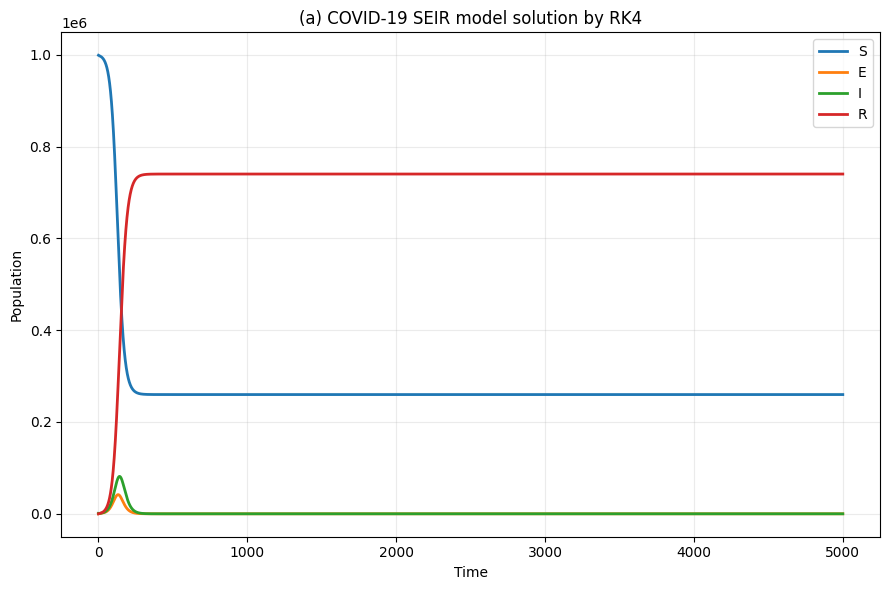

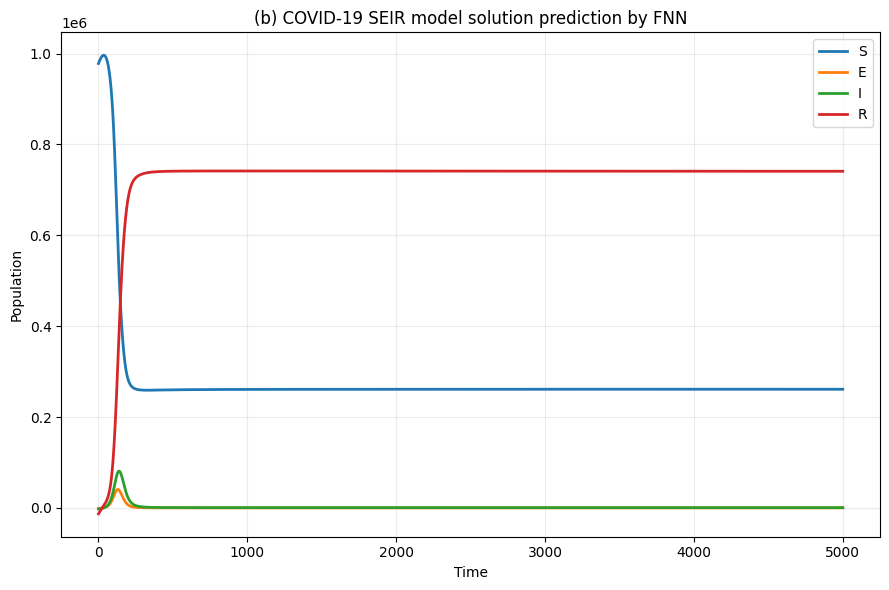

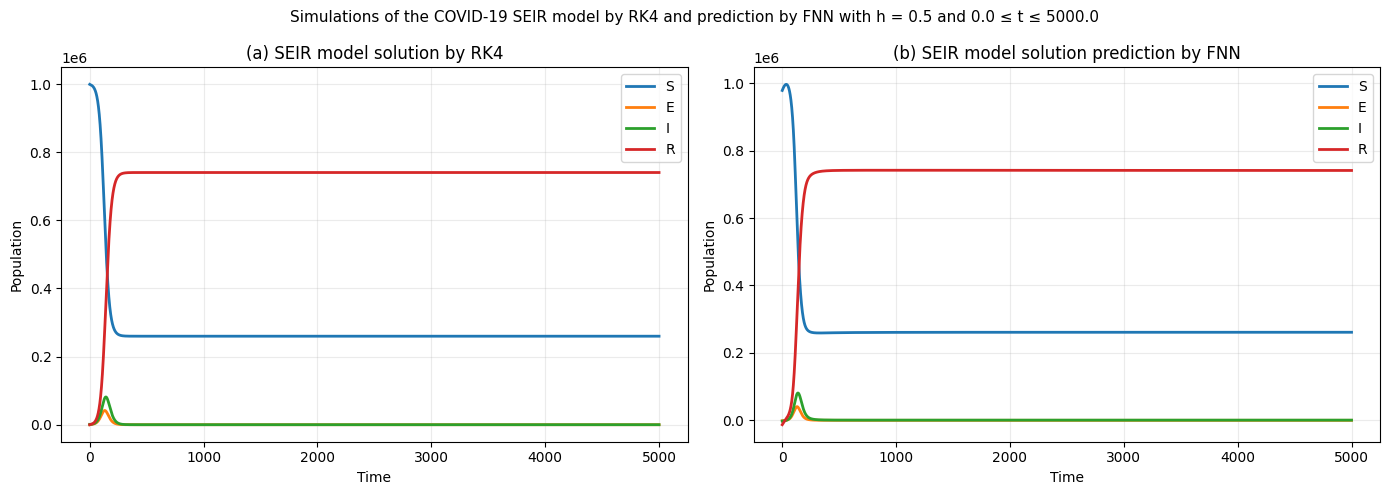

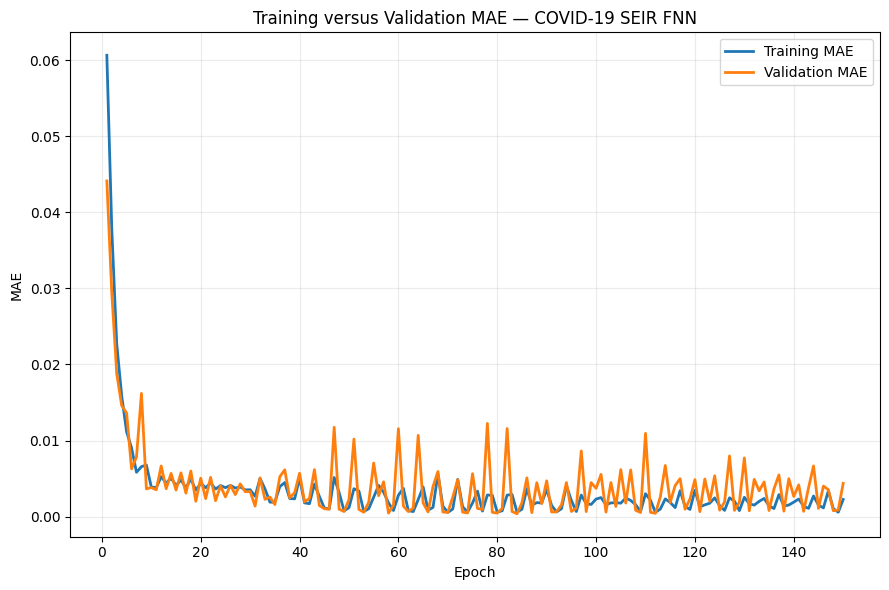

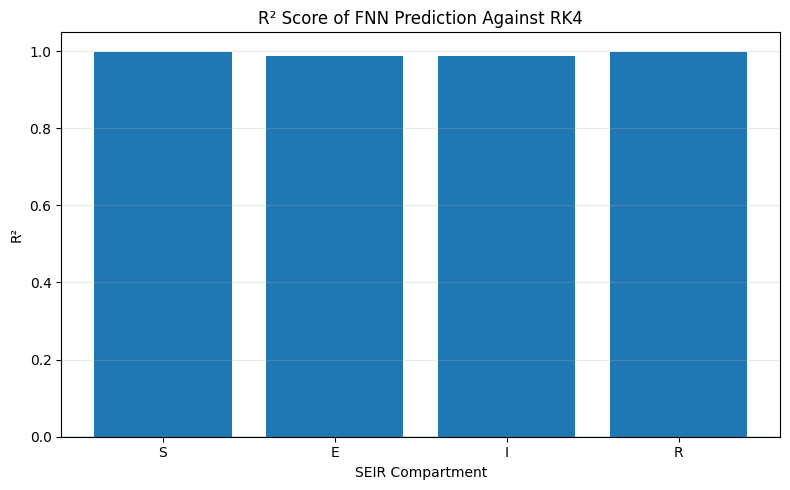

/tmp/ipykernel_95/3678915318.py:1075: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  rk4.to_excel(
/tmp/ipykernel_95/3678915318.py:1081: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  res.to_excel(
/tmp/ipykernel_95/3678915318.py:1087: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  metrics.to_excel(
/tmp/ipykernel_95/3678915318.py:1093: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  normdf.to_excel(
/tmp/ipykernel_95/3678915318.py:1099: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  Hdf.to_excel(
/tmp/ipykernel_95/3678915318.py:1105: FutureWarn


COVID-19 SEIR RK4 + FNN EXPERIMENT COMPLETED
beta = 0.17150948
gamma = 0.09425424
sigma = 0.19230769
latent period = 5.20 days
beta/gamma = 1.819647

Initial state: S0=999,000, E0=0, I0=1,000, R0=0
N = 1,000,000

RK4: h=0.5, t=[0.0,5000.0], samples=10,001

Metrics (FNN vs RK4):
Compartment         MAE          MSE        RMSE       R2
          S 1940.653667 1.681622e+07 4100.758428 0.998510
          E  134.361332 2.843884e+05  533.280822 0.986281
          I  692.519063 1.022104e+06 1010.991575 0.987683
          R 1964.095479 3.729509e+07 6106.970383 0.997090

Normalized accuracy-like score:
Compartment  Normalized_MAE  Normalized_MSE  Accuracy_like_percent
          S        0.002625        0.000031              99.737476
          E        0.003099        0.000156              99.690129
          I        0.008374        0.000147              99.162568
          R        0.002609        0.000067              99.739074

Population conservation check:
RK4 maximum absolute error = 0

In [2]:
import os, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


# ============================================================
# COVID-19 SEIR RK4-FNN Synthetic Experiment
#
# Method:
#   1. Generate synthetic SEIR data using RK4
#   2. Min-Max normalization
#   3. 80/20 train-validation split
#   4. FNN input = t
#   5. FNN output = [S(t), E(t), I(t), R(t)]
#   6. MSE loss
#   7. Adam optimizer
#   8. tanh activation
#   9. 150 epochs
#
# SEIR compartments:
#   S = Susceptible
#   E = Exposed
#   I = Infectious
#   R = Recovered
# ============================================================


# ============================================================
# Output directory
# ============================================================

OUT = Path('/kaggle/working/COVID19_SEIR_RK4_FNN_synthetic_article_method')
OUT.mkdir(parents=True, exist_ok=True)


# ============================================================
# SEIR PARAMETERS
# ============================================================

BETA = 0.17150948
GAMMA = 0.09425424

# Sigma = rate at which exposed individuals become infectious
# Mean latent/incubation period = 1 / SIGMA
SIGMA = 1.0 / 5.2

# Initial conditions
S0 = 999000.0
E0 = 0.0
I0 = 1000.0
R0 = 0.0

# Total population
N = S0 + E0 + I0 + R0


# ============================================================
# TIME SETTINGS
# ============================================================

T0 = 0.0
T1 = 5000.0
H = 0.5


# ============================================================
# FNN SETTINGS
# ============================================================

SEED = 42

EPOCHS = 150
BATCH_SIZE = 32

# Same published-style architecture as your SIR code
HIDDEN = [16, 128, 80, 40, 16]


# ============================================================
# RANDOM SEED
# ============================================================

os.environ['PYTHONHASHSEED'] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass


# ============================================================
# SEIR DIFFERENTIAL EQUATIONS
# ============================================================
#
# dS/dt = -beta*S*I/N
#
# dE/dt = beta*S*I/N - sigma*E
#
# dI/dt = sigma*E - gamma*I
#
# dR/dt = gamma*I
#
# ============================================================

def rhs(t, y):

    S, E, I, R = y

    dS = -BETA * S * I / N

    dE = BETA * S * I / N - SIGMA * E

    dI = SIGMA * E - GAMMA * I

    dR = GAMMA * I

    return np.array([dS, dE, dI, dR])


# ============================================================
# RK4 ONE STEP
# ============================================================

def rk4_step(t, y, h):

    k1 = h * rhs(t, y)

    k2 = h * rhs(
        t + h / 2,
        y + k1 / 2
    )

    k3 = h * rhs(
        t + h / 2,
        y + k2 / 2
    )

    k4 = h * rhs(
        t + h,
        y + k3
    )

    y_next = y + (
        k1 + 2*k2 + 2*k3 + k4
    ) / 6

    # Avoid negative populations
    y_next = np.maximum(y_next, 0.0)

    return y_next


# ============================================================
# GENERATE TIME ARRAY
# ============================================================

t = np.arange(
    T0,
    T1 + H / 2,
    H
)

t[-1] = T1


# ============================================================
# RK4 SYNTHETIC DATA GENERATION
# ============================================================

y = np.zeros(
    (len(t), 4)
)

# Initial conditions
y[0] = [
    S0,
    E0,
    I0,
    R0
]


# Run RK4
for j in range(len(t) - 1):

    y[j + 1] = rk4_step(
        t[j],
        y[j],
        H
    )


# ============================================================
# CREATE RK4 DATAFRAME
# ============================================================

rk4 = pd.DataFrame({
    't': t,
    'S_RK4': y[:, 0],
    'E_RK4': y[:, 1],
    'I_RK4': y[:, 2],
    'R_RK4': y[:, 3]
})


# Total population
rk4['Total_RK4'] = rk4[
    [
        'S_RK4',
        'E_RK4',
        'I_RK4',
        'R_RK4'
    ]
].sum(axis=1)


# Population conservation error
rk4['Population_Error'] = (
    rk4['Total_RK4'] - N
)


# Save RK4 synthetic dataset
rk4.to_csv(
    OUT / 'COVID19_SEIR_RK4_synthetic_data.csv',
    index=False
)


# ============================================================
# ARTICLE-STYLE FNN
# ============================================================
#
# Input:
#       t
#
# Output:
#       S(t), E(t), I(t), R(t)
#
# ============================================================

X = t.reshape(-1, 1)

Y = y.copy()


# ============================================================
# MIN-MAX NORMALIZATION
# ============================================================

xsc = MinMaxScaler()

ysc = MinMaxScaler()


Xs = xsc.fit_transform(X)

Ys = ysc.fit_transform(Y)


# ============================================================
# 80/20 TRAIN-VALIDATION SPLIT
# ============================================================

Xtr, Xva, Ytr, Yva = train_test_split(
    Xs,
    Ys,
    test_size=0.20,
    random_state=SEED,
    shuffle=True
)


# ============================================================
# BUILD FNN
# ============================================================

model = keras.Sequential(
    [
        layers.Input((1,))
    ]
    +
    [
        layers.Dense(
            u,
            activation='tanh'
        )
        for u in HIDDEN
    ]
    +
    [
        layers.Dense(
            4,
            activation='linear'
        )
    ],
    name='COVID19_SEIR_FNN'
)


# ============================================================
# COMPILE MODEL
# ============================================================

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss='mse',
    metrics=[
        keras.metrics.MeanAbsoluteError(
            name='mae'
        )
    ]
)


print(model.summary())


# ============================================================
# TRAIN FNN
# ============================================================

hist = model.fit(
    Xtr,
    Ytr,
    validation_data=(Xva, Yva),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    verbose=1
)


# ============================================================
# TRAINING HISTORY
# ============================================================

Hdf = pd.DataFrame(
    hist.history
)

Hdf.insert(
    0,
    'epoch',
    np.arange(
        1,
        len(Hdf) + 1
    )
)


Hdf.to_csv(
    OUT / 'FNN_training_history.csv',
    index=False
)


# ============================================================
# FULL-DOMAIN FNN PREDICTION
# ============================================================

pred_scaled = model.predict(
    Xs,
    batch_size=BATCH_SIZE,
    verbose=1
)


# Convert back to original population scale
pred = ysc.inverse_transform(
    pred_scaled
)


# ============================================================
# EXTRACT COMPARTMENTS
# ============================================================

Sfnn = pred[:, 0]
Efnn = pred[:, 1]
Ifnn = pred[:, 2]
Rfnn = pred[:, 3]


# Optional non-negative predictions
Sfnn = np.maximum(
    Sfnn,
    0
)

Efnn = np.maximum(
    Efnn,
    0
)

Ifnn = np.maximum(
    Ifnn,
    0
)

Rfnn = np.maximum(
    Rfnn,
    0
)


# ============================================================
# RESULTS DATAFRAME
# ============================================================

res = pd.DataFrame({

    't': t,

    'S_RK4': y[:, 0],
    'E_RK4': y[:, 1],
    'I_RK4': y[:, 2],
    'R_RK4': y[:, 3],

    'S_FNN': Sfnn,
    'E_FNN': Efnn,
    'I_FNN': Ifnn,
    'R_FNN': Rfnn
})


# ============================================================
# TOTAL POPULATION
# ============================================================

res['RK4_Total'] = res[
    [
        'S_RK4',
        'E_RK4',
        'I_RK4',
        'R_RK4'
    ]
].sum(axis=1)


res['FNN_Total'] = res[
    [
        'S_FNN',
        'E_FNN',
        'I_FNN',
        'R_FNN'
    ]
].sum(axis=1)


# ============================================================
# FNN TOTAL POPULATION ERROR
# ============================================================

res['FNN_Total_Error'] = (
    res['FNN_Total'] - N
)


# ============================================================
# COMPARTMENT-WISE ERRORS
# ============================================================

res['S_Error'] = (
    res['S_FNN'] - res['S_RK4']
)

res['E_Error'] = (
    res['E_FNN'] - res['E_RK4']
)

res['I_Error'] = (
    res['I_FNN'] - res['I_RK4']
)

res['R_Error'] = (
    res['R_FNN'] - res['R_RK4']
)


# Save complete results
res.to_csv(
    OUT / 'COVID19_SEIR_RK4_vs_FNN_complete.csv',
    index=False
)


# ============================================================
# METRICS
# ============================================================

rows = []


for k, name in enumerate(
    ['S', 'E', 'I', 'R']
):

    actual = y[:, k]

    prediction = pred[:, k]


    mse = mean_squared_error(
        actual,
        prediction
    )


    rows.append({

        'Compartment': name,

        'MAE': mean_absolute_error(
            actual,
            prediction
        ),

        'MSE': mse,

        'RMSE': np.sqrt(mse),

        'R2': r2_score(
            actual,
            prediction
        )

    })


metrics = pd.DataFrame(
    rows
)


metrics.to_csv(
    OUT / 'COVID19_SEIR_RK4_FNN_metrics.csv',
    index=False
)


# ============================================================
# NORMALIZED MAE / ACCURACY-LIKE SCORE
# ============================================================

norm = []


# Use non-negative predictions for this section
P_for_scaling = np.column_stack(
    [
        Sfnn,
        Efnn,
        Ifnn,
        Rfnn
    ]
)


Pscaled = ysc.transform(
    P_for_scaling
)


for k, name in enumerate(
    ['S', 'E', 'I', 'R']
):

    mae = mean_absolute_error(
        Ys[:, k],
        Pscaled[:, k]
    )

    mse = mean_squared_error(
        Ys[:, k],
        Pscaled[:, k]
    )


    norm.append({

        'Compartment': name,

        'Normalized_MAE': mae,

        'Normalized_MSE': mse,

        'Accuracy_like_percent':
            (1 - mae) * 100

    })


normdf = pd.DataFrame(
    norm
)


normdf.to_csv(
    OUT / 'COVID19_SEIR_FNN_normalized_accuracy.csv',
    index=False
)


# ============================================================
# FIGURE 1
# RK4 SEIR SOLUTION
# ============================================================

plt.figure(
    figsize=(9, 6)
)


plt.plot(
    t,
    y[:, 0],
    label='S',
    linewidth=2
)

plt.plot(
    t,
    y[:, 1],
    label='E',
    linewidth=2
)

plt.plot(
    t,
    y[:, 2],
    label='I',
    linewidth=2
)

plt.plot(
    t,
    y[:, 3],
    label='R',
    linewidth=2
)


plt.title(
    '(a) COVID-19 SEIR model solution by RK4'
)

plt.xlabel('Time')

plt.ylabel('Population')

plt.legend()

plt.grid(alpha=0.25)

plt.tight_layout()


plt.savefig(
    OUT / 'Figure_RK4_SEIR.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# FIGURE 2
# FNN SEIR PREDICTION
# ============================================================

plt.figure(
    figsize=(9, 6)
)


plt.plot(
    t,
    pred[:, 0],
    label='S',
    linewidth=2
)

plt.plot(
    t,
    pred[:, 1],
    label='E',
    linewidth=2
)

plt.plot(
    t,
    pred[:, 2],
    label='I',
    linewidth=2
)

plt.plot(
    t,
    pred[:, 3],
    label='R',
    linewidth=2
)


plt.title(
    '(b) COVID-19 SEIR model solution prediction by FNN'
)

plt.xlabel('Time')

plt.ylabel('Population')

plt.legend()

plt.grid(alpha=0.25)

plt.tight_layout()


plt.savefig(
    OUT / 'Figure_FNN_SEIR.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# FIGURE 3
# RK4 VS FNN — SIDE BY SIDE
# ============================================================

fig, ax = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)


# ------------------------------------------------------------
# RK4
# ------------------------------------------------------------

ax[0].plot(
    t,
    y[:, 0],
    label='S',
    linewidth=2
)

ax[0].plot(
    t,
    y[:, 1],
    label='E',
    linewidth=2
)

ax[0].plot(
    t,
    y[:, 2],
    label='I',
    linewidth=2
)

ax[0].plot(
    t,
    y[:, 3],
    label='R',
    linewidth=2
)


ax[0].set_title(
    '(a) SEIR model solution by RK4'
)

ax[0].set_xlabel('Time')

ax[0].set_ylabel('Population')

ax[0].legend()

ax[0].grid(alpha=0.25)


# ------------------------------------------------------------
# FNN
# ------------------------------------------------------------

ax[1].plot(
    t,
    pred[:, 0],
    label='S',
    linewidth=2
)

ax[1].plot(
    t,
    pred[:, 1],
    label='E',
    linewidth=2
)

ax[1].plot(
    t,
    pred[:, 2],
    label='I',
    linewidth=2
)

ax[1].plot(
    t,
    pred[:, 3],
    label='R',
    linewidth=2
)


ax[1].set_title(
    '(b) SEIR model solution prediction by FNN'
)

ax[1].set_xlabel('Time')

ax[1].set_ylabel('Population')

ax[1].legend()

ax[1].grid(alpha=0.25)


fig.suptitle(
    f'Simulations of the COVID-19 SEIR model '
    f'by RK4 and prediction by FNN '
    f'with h = {H} and '
    f'{T0} ≤ t ≤ {T1}',
    fontsize=11
)


fig.tight_layout()


fig.savefig(
    OUT / 'Figure_RK4_vs_FNN_SEIR.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# FIGURE 4
# TRAINING VS VALIDATION MAE
# ============================================================

plt.figure(
    figsize=(9, 6)
)


plt.plot(
    Hdf.epoch,
    Hdf.mae,
    label='Training MAE',
    linewidth=2
)

plt.plot(
    Hdf.epoch,
    Hdf.val_mae,
    label='Validation MAE',
    linewidth=2
)


plt.xlabel('Epoch')

plt.ylabel('MAE')

plt.title(
    'Training versus Validation MAE — COVID-19 SEIR FNN'
)

plt.legend()

plt.grid(alpha=0.25)

plt.tight_layout()


plt.savefig(
    OUT / 'Figure_Training_Validation_MAE_SEIR.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# FIGURE 5
# R2 BAR CHART
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.bar(
    metrics['Compartment'],
    metrics['R2']
)


plt.axhline(
    0,
    linewidth=1
)


plt.xlabel('SEIR Compartment')

plt.ylabel('R²')

plt.title(
    'R² Score of FNN Prediction Against RK4'
)

plt.grid(
    axis='y',
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    OUT / 'Figure_R2_SEIR_FNN.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# EXCEL OUTPUT
# ============================================================

params = pd.DataFrame({

    'Parameter': [

        'Beta',
        'Gamma',
        'Sigma',
        '1/Sigma',
        'Beta/Gamma',

        'S0',
        'E0',
        'I0',
        'R0',

        'N',

        'Time_start',
        'Time_end',

        'Step_h',

        'Samples',

        'FNN_input',

        'FNN_output',

        'Normalization',

        'Train',

        'Validation',

        'Random_state',

        'Activation',

        'Optimizer',

        'Hidden_layers',

        'Epochs',

        'Batch_size'

    ],


    'Value': [

        BETA,
        GAMMA,
        SIGMA,
        1 / SIGMA,
        BETA / GAMMA,

        S0,
        E0,
        I0,
        R0,

        N,

        T0,
        T1,

        H,

        len(t),

        't',

        'S(t), E(t), I(t), R(t)',

        'Min-Max [0,1]',

        '80%',

        '20%',

        SEED,

        'tanh',

        'Adam',

        str(HIDDEN),

        EPOCHS,

        BATCH_SIZE

    ]

})


with pd.ExcelWriter(
    OUT / 'COVID19_SEIR_RK4_FNN_complete_results.xlsx',
    engine='openpyxl'
) as writer:

    rk4.to_excel(
        writer,
        'RK4_Data',
        index=False
    )

    res.to_excel(
        writer,
        'RK4_vs_FNN',
        index=False
    )

    metrics.to_excel(
        writer,
        'Metrics',
        index=False
    )

    normdf.to_excel(
        writer,
        'Normalized_Accuracy',
        index=False
    )

    Hdf.to_excel(
        writer,
        'Training_History',
        index=False
    )

    params.to_excel(
        writer,
        'Parameters',
        index=False
    )


# ============================================================
# SAVE MODEL
# ============================================================

model.save(
    OUT / 'COVID19_SEIR_FNN.keras'
)


# ============================================================
# FINAL SUMMARY
# ============================================================

print('\n' + '=' * 80)

print('COVID-19 SEIR RK4 + FNN EXPERIMENT COMPLETED')

print('=' * 80)


print(
    f'beta = {BETA:.8f}'
)

print(
    f'gamma = {GAMMA:.8f}'
)

print(
    f'sigma = {SIGMA:.8f}'
)

print(
    f'latent period = {1/SIGMA:.2f} days'
)

print(
    f'beta/gamma = {BETA/GAMMA:.6f}'
)


print(
    f'\nInitial state: '
    f'S0={S0:,.0f}, '
    f'E0={E0:,.0f}, '
    f'I0={I0:,.0f}, '
    f'R0={R0:,.0f}'
)


print(
    f'N = {N:,.0f}'
)


print(
    f'\nRK4: h={H}, '
    f't=[{T0},{T1}], '
    f'samples={len(t):,}'
)


print(
    '\nMetrics (FNN vs RK4):'
)

print(
    metrics.to_string(
        index=False
    )
)


print(
    '\nNormalized accuracy-like score:'
)

print(
    normdf.to_string(
        index=False
    )
)


print(
    '\nPopulation conservation check:'
)

print(
    f'RK4 maximum absolute error = '
    f'{np.max(np.abs(rk4["Population_Error"])):.10f}'
)


print(
    '\nOutputs saved to:'
)

print(
    OUT
)

print('=' * 80)

# COVID-19 SIR RK4-FNN synthetic experiment

Model: "COVID19_SIR_FNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 80)             │        10,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 40)             │         3,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,475 (64.36 KB)

 Trainable params: 16,475 (64.36 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/150
234/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0457 - mae: 0.0986

2026-09-03 06:23:56.516382: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0177 - mae: 0.0545 - val_loss: 0.0099 - val_mae: 0.0386
Epoch 2/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0079 - mae: 0.0352 - val_loss: 0.0072 - val_mae: 0.0303
Epoch 3/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0050 - mae: 0.0245 - val_loss: 0.0049 - val_mae: 0.0203
Epoch 4/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0028 - mae: 0.0151 - val_loss: 0.0034 - val_mae: 0.0132
Epoch 5/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0022 - mae: 0.0114 - val_loss: 0.0021 - val_mae: 0.0097
Epoch 6/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0017 - mae: 0.0095 - val_loss: 0.0011 - val_mae: 0.0065
Epoch 7/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0012 - mae: 0.0080 - val_loss: 4.0442e-04 - val_mae: 0.0044
Epoch 8/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.0956e-04 - mae: 0.0062 - val_loss: 1.8191e-04 - val_mae: 0.0043
Epoch 9/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/

2026-09-03 06:25:42.500393: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


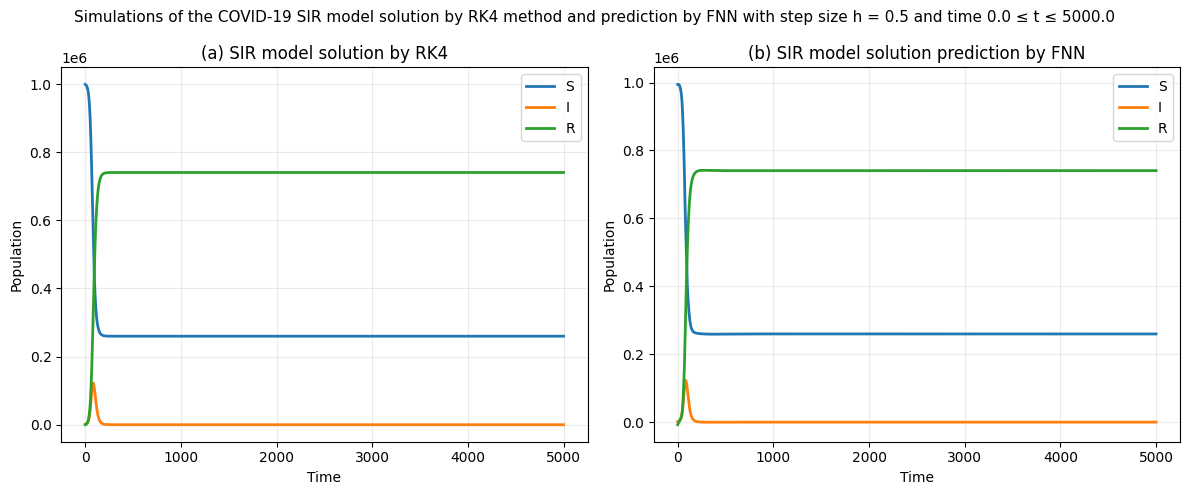

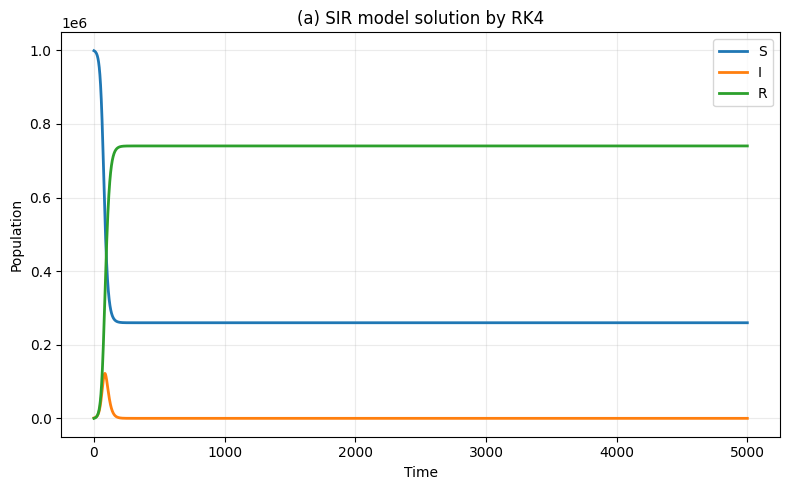

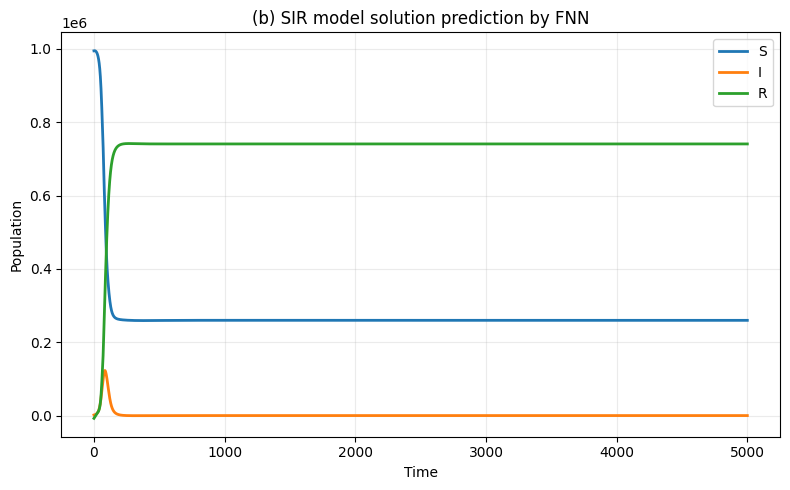

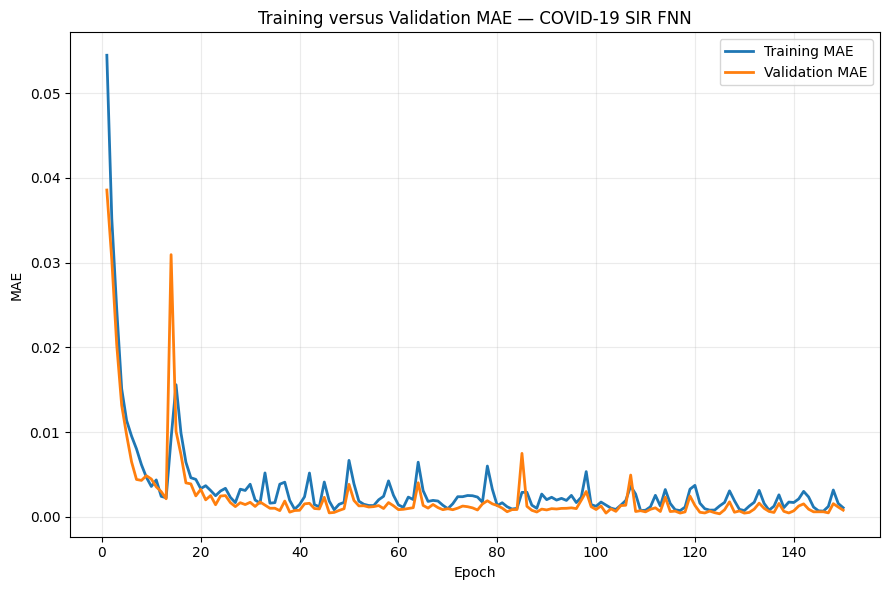

/tmp/ipykernel_95/3891556176.py:113: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  rk4.to_excel(w,'RK4_Data',index=False); res.to_excel(w,'RK4_vs_FNN',index=False); metrics.to_excel(w,'Metrics',index=False); normdf.to_excel(w,'Normalized_Accuracy',index=False); Hdf.to_excel(w,'Training_History',index=False); params.to_excel(w,'Parameters',index=False)



DONE
beta=0.17150948, gamma=0.09425424, beta/gamma=1.819647
Initial state: S0=999,000, I0=1,000, R0=0, N=1,000,000
RK4: h=0.5, t=[0.0,5000.0], samples=10,001

Metrics (FNN vs RK4):
Compartment        MAE          MSE        RMSE       R2
          S 237.904765 1.467337e+06 1211.336959 0.999787
          I 160.975846 6.749455e+04  259.797130 0.999459
          R 521.109094 1.583646e+06 1258.430016 0.999799

Normalized accuracy-like score:
Compartment  Normalized_MAE  Normalized_MSE  Accuracy_like_percent
          S        0.000322        0.000003              99.967817
          I        0.001282        0.000004              99.871751
          R        0.000689        0.000003              99.931056

Outputs: /kaggle/working/COVID19_SIR_RK4_FNN_synthetic_article_method


In [3]:
# ============================================================
# COVID-19 SIR RK4-FNN synthetic experiment
# Method follows the supplied article: RK4-generated data,
# min-max scaling, 80/20 train-validation split, FNN input=t,
# output=[S(t),I(t),R(t)], MSE loss, Adam, tanh, 150 epochs.
# ============================================================

OUT = Path('/kaggle/working/COVID19_SIR_RK4_FNN_synthetic_article_method')
OUT.mkdir(parents=True, exist_ok=True)

BETA = 0.17150948
GAMMA = 0.09425424
S0, I0, R0 = 999000.0, 1000.0, 0.0   # edit if desired
N = S0 + I0 + R0
T0, T1, H = 0.0, 5000.0, 0.5
SEED = 42
EPOCHS, BATCH_SIZE = 150, 32
HIDDEN = [16, 128, 80, 40, 16]  # published best SIR configuration

os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
try: tf.config.experimental.enable_op_determinism()
except Exception: pass

# -------------------- SIR equations ---------------------------
def rhs(t, y):
    S, I, R = y
    return np.array([-BETA*S*I/N, BETA*S*I/N-GAMMA*I, GAMMA*I])

def rk4_step(t, y, h):
    k1 = h*rhs(t, y)
    k2 = h*rhs(t+h/2, y+k1/2)
    k3 = h*rhs(t+h/2, y+k2/2)
    k4 = h*rhs(t+h, y+k3)
    return np.maximum(y+(k1+2*k2+2*k3+k4)/6, 0.0)

# -------------------- RK4 synthetic data -----------------------
t = np.arange(T0, T1+H/2, H)
t[-1] = T1
y = np.zeros((len(t),3)); y[0] = [S0,I0,R0]
for j in range(len(t)-1): y[j+1] = rk4_step(t[j], y[j], H)

rk4 = pd.DataFrame({'t':t,'S_RK4':y[:,0],'I_RK4':y[:,1],'R_RK4':y[:,2]})
rk4['Total_RK4'] = rk4[['S_RK4','I_RK4','R_RK4']].sum(axis=1)
rk4.to_csv(OUT/'COVID19_SIR_RK4_synthetic_data.csv', index=False)

# -------------------- Article-style FNN ------------------------
# Article maps time t -> S,I,R (not state(t)->state(t+h)).
X, Y = t.reshape(-1,1), y.copy()
xsc, ysc = MinMaxScaler(), MinMaxScaler()
Xs, Ys = xsc.fit_transform(X), ysc.fit_transform(Y)
Xtr, Xva, Ytr, Yva = train_test_split(Xs, Ys, test_size=.20, random_state=SEED, shuffle=True)

model = keras.Sequential([layers.Input((1,))] +
    [layers.Dense(u, activation='tanh') for u in HIDDEN] +
    [layers.Dense(3, activation='linear')], name='COVID19_SIR_FNN')
model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss='mse', metrics=[keras.metrics.MeanAbsoluteError(name='mae')])
print(model.summary())
hist = model.fit(Xtr, Ytr, validation_data=(Xva,Yva), epochs=EPOCHS, batch_size=BATCH_SIZE, shuffle=True, verbose=1)

Hdf = pd.DataFrame(hist.history); Hdf.insert(0,'epoch',np.arange(1,len(Hdf)+1)); Hdf.to_csv(OUT/'FNN_training_history.csv',index=False)

# Full-domain FNN prediction, as in article tables/figure
pred = ysc.inverse_transform(model.predict(Xs,batch_size=BATCH_SIZE,verbose=1))
Sfnn, Ifnn, Rfnn = pred.T

# Raw network predictions are retained; optional nonnegative version is used for plots/metrics.
Sfnn = np.maximum(Sfnn,0); Ifnn=np.maximum(Ifnn,0); Rfnn=np.maximum(Rfnn,0)

res = pd.DataFrame({'t':t,'S_RK4':y[:,0],'I_RK4':y[:,1],'R_RK4':y[:,2],
                    'S_FNN':Sfnn,'I_FNN':Ifnn,'R_FNN':Rfnn})
res['RK4_Total']=res[['S_RK4','I_RK4','R_RK4']].sum(axis=1)
res['FNN_Total']=res[['S_FNN','I_FNN','R_FNN']].sum(axis=1)
res['FNN_Total_Error']=res['FNN_Total']-N
res.to_csv(OUT/'COVID19_SIR_RK4_vs_FNN_complete.csv',index=False)

# -------------------- Metrics ----------------------------------
rows=[]
for k,name in enumerate(['S','I','R']):
    a,p=y[:,k],pred[:,k]
    rows.append({'Compartment':name,'MAE':mean_absolute_error(a,p),
                 'MSE':mean_squared_error(a,p),'RMSE':np.sqrt(mean_squared_error(a,p)),
                 'R2':r2_score(a,p)})
metrics=pd.DataFrame(rows); metrics.to_csv(OUT/'COVID19_SIR_RK4_FNN_metrics.csv',index=False)

# Article-style normalized MAE and accuracy-like score
norm=[]
Pscaled=ysc.transform(np.column_stack([Sfnn,Ifnn,Rfnn]))
for k,name in enumerate(['S','I','R']):
    mae=mean_absolute_error(Ys[:,k],Pscaled[:,k])
    norm.append({'Compartment':name,'Normalized_MAE':mae,'Normalized_MSE':mean_squared_error(Ys[:,k],Pscaled[:,k]),'Accuracy_like_percent':(1-mae)*100})
normdf=pd.DataFrame(norm); normdf.to_csv(OUT/'COVID19_SIR_FNN_normalized_accuracy.csv',index=False)

# -------------------- Figure 2 style ---------------------------
fig, ax = plt.subplots(1,2,figsize=(12,5))
for a, data, title in [(ax[0],y,'(a) SIR model solution by RK4'),(ax[1],pred,'(b) SIR model solution prediction by FNN')]:
    a.plot(t,data[:,0],label='S',linewidth=2); a.plot(t,data[:,1],label='I',linewidth=2); a.plot(t,data[:,2],label='R',linewidth=2)
    a.set_title(title); a.set_xlabel('Time'); a.set_ylabel('Population'); a.legend(); a.grid(alpha=.25)
fig.suptitle(f'Simulations of the COVID-19 SIR model solution by RK4 method and prediction by FNN with step size h = {H} and time {T0} ≤ t ≤ {T1}',fontsize=11)
fig.tight_layout(); fig.savefig(OUT/'Figure2_COVID19_SIR_RK4_vs_FNN.png',dpi=300,bbox_inches='tight'); plt.show()

# Individual panels
for data,title,file in [(y,'(a) SIR model solution by RK4','Figure2a_RK4_SIR.png'),(pred,'(b) SIR model solution prediction by FNN','Figure2b_FNN_SIR.png')]:
    plt.figure(figsize=(8,5)); plt.plot(t,data[:,0],label='S',lw=2); plt.plot(t,data[:,1],label='I',lw=2); plt.plot(t,data[:,2],label='R',lw=2); plt.title(title); plt.xlabel('Time'); plt.ylabel('Population'); plt.legend(); plt.grid(alpha=.25); plt.tight_layout(); plt.savefig(OUT/file,dpi=300,bbox_inches='tight'); plt.show()

# Figure 4 style training/validation MAE
plt.figure(figsize=(9,6)); plt.plot(Hdf.epoch,Hdf.mae,label='Training MAE',lw=2); plt.plot(Hdf.epoch,Hdf.val_mae,label='Validation MAE',lw=2); plt.xlabel('Epoch'); plt.ylabel('MAE'); plt.title('Training versus Validation MAE — COVID-19 SIR FNN'); plt.legend(); plt.grid(alpha=.25); plt.tight_layout(); plt.savefig(OUT/'Figure4_style_training_validation_MAE.png',dpi=300,bbox_inches='tight'); plt.show()

# -------------------- Excel ------------------------------------
params=pd.DataFrame({'Parameter':['Beta','Gamma','beta/gamma','S0','I0','R0','N','Time_start','Time_end','Step_h','Samples','FNN_input','FNN_output','Normalization','Train','Validation','Random_state','Activation','Optimizer','Hidden_layers','Epochs','Batch_size'],
                     'Value':[BETA,GAMMA,BETA/GAMMA,S0,I0,R0,N,T0,T1,H,len(t),'t','S(t), I(t), R(t)','Min-Max [0,1]','80%','20%',SEED,'tanh','Adam',str(HIDDEN),EPOCHS,BATCH_SIZE]})
with pd.ExcelWriter(OUT/'COVID19_SIR_RK4_FNN_complete_results.xlsx',engine='openpyxl') as w:
    rk4.to_excel(w,'RK4_Data',index=False); res.to_excel(w,'RK4_vs_FNN',index=False); metrics.to_excel(w,'Metrics',index=False); normdf.to_excel(w,'Normalized_Accuracy',index=False); Hdf.to_excel(w,'Training_History',index=False); params.to_excel(w,'Parameters',index=False)
model.save(OUT/'COVID19_SIR_FNN.keras')

print('\n'+'='*75); print('DONE'); print('='*75)
print(f'beta={BETA:.8f}, gamma={GAMMA:.8f}, beta/gamma={BETA/GAMMA:.6f}')
print(f'Initial state: S0={S0:,.0f}, I0={I0:,.0f}, R0={R0:,.0f}, N={N:,.0f}')
print(f'RK4: h={H}, t=[{T0},{T1}], samples={len(t):,}')
print('\nMetrics (FNN vs RK4):'); print(metrics.to_string(index=False))
print('\nNormalized accuracy-like score:'); print(normdf.to_string(index=False))
print('\nOutputs:', OUT)

Model: "COVID19_SEIR_FNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 80)             │        10,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 40)             │         3,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,492 (64.42 KB)

 Trainable params: 16,492 (64.42 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/150
244/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0356 - mae: 0.0970

2026-09-03 06:25:52.540154: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0180 - mae: 0.0606 - val_loss: 0.0121 - val_mae: 0.0441
Epoch 2/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0084 - mae: 0.0377 - val_loss: 0.0066 - val_mae: 0.0294
Epoch 3/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0044 - mae: 0.0227 - val_loss: 0.0039 - val_mae: 0.0188
Epoch 4/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0025 - mae: 0.0159 - val_loss: 0.0019 - val_mae: 0.0146
Epoch 5/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0013 - mae: 0.0111 - val_loss: 0.0014 - val_mae: 0.0136
Epoch 6/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.5927e-04 - mae: 0.0090 - val_loss: 2.4520e-04 - val_mae: 0.0063
Epoch 7/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.1409e-04 - mae: 0.0058 - val_loss: 3.8072e-04 - val_mae: 0.0078
Epoch 8/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.0923e-04 - mae: 0.0066 - val_loss: 0.0022 - val_mae: 0.0162
Epoch 9/150
250/250 ━━━━━━━━━━━━━━━━━━━━

2026-09-03 06:27:40.705548: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


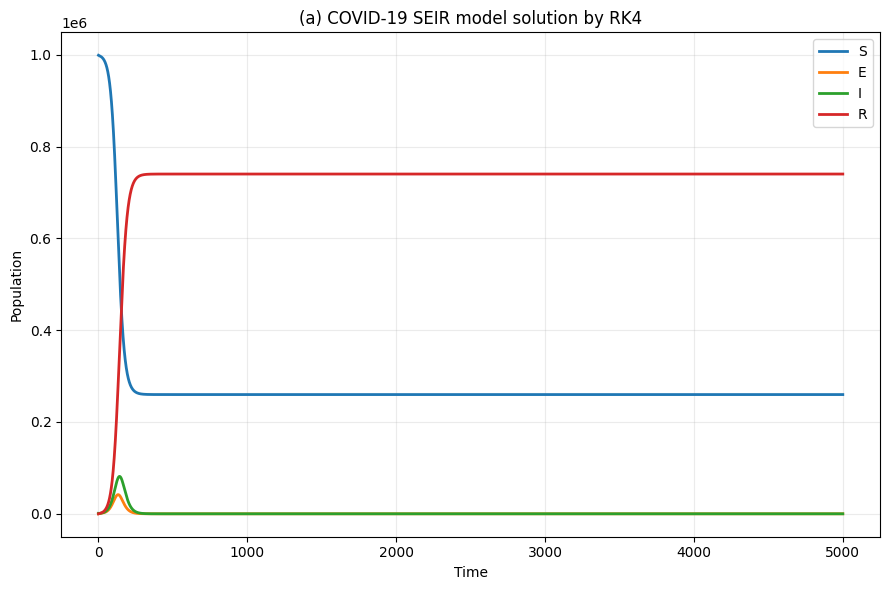

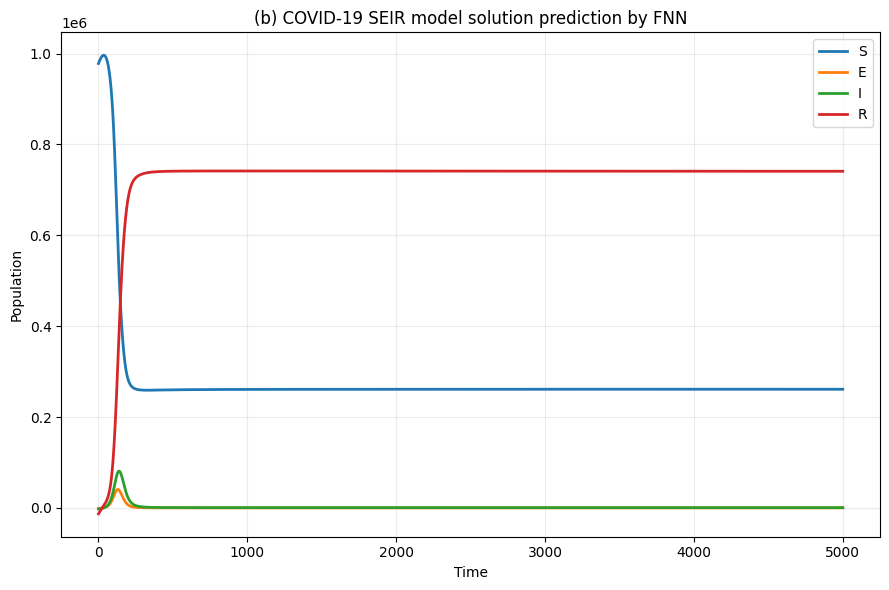

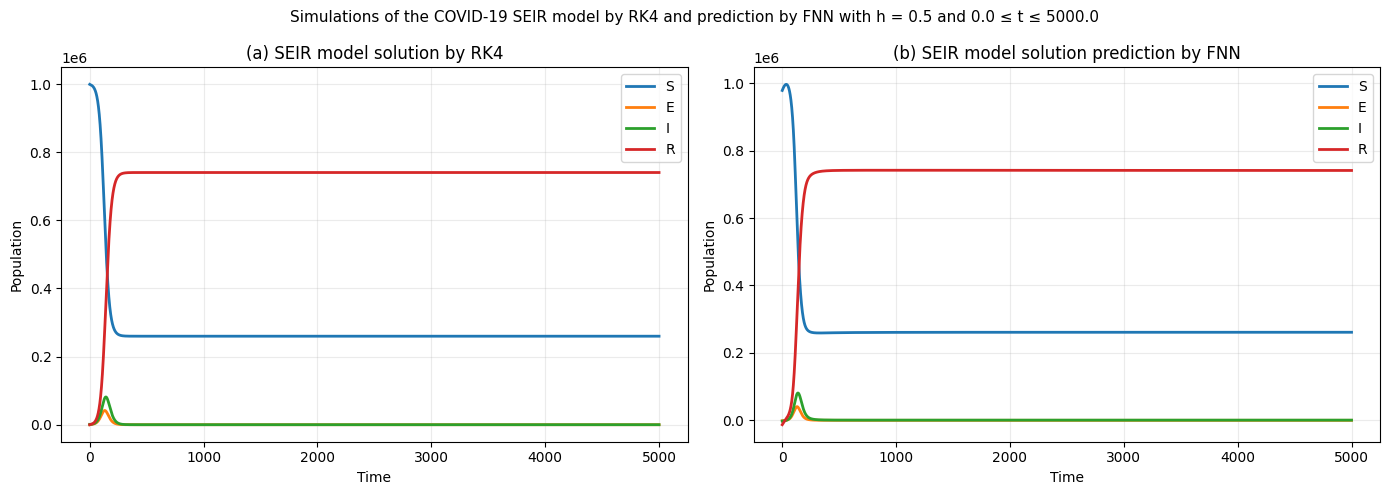

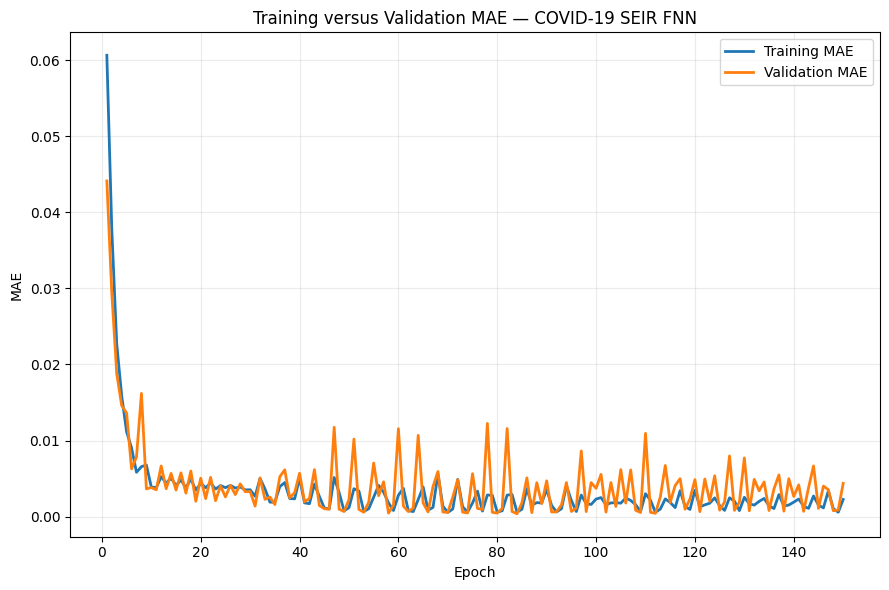

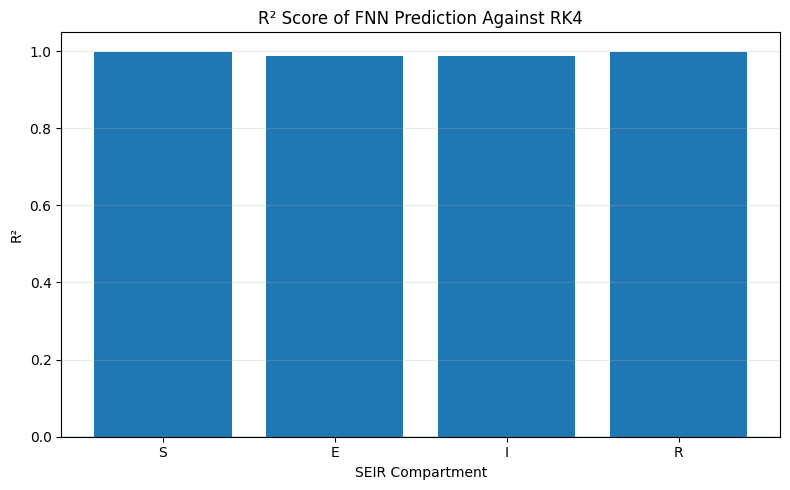

/tmp/ipykernel_95/4186797239.py:1038: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  rk4.to_excel(
/tmp/ipykernel_95/4186797239.py:1044: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  res.to_excel(
/tmp/ipykernel_95/4186797239.py:1050: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  metrics.to_excel(
/tmp/ipykernel_95/4186797239.py:1056: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  normdf.to_excel(
/tmp/ipykernel_95/4186797239.py:1062: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  Hdf.to_excel(
/tmp/ipykernel_95/4186797239.py:1068: FutureWarn


COVID-19 SEIR RK4 + FNN EXPERIMENT COMPLETED
beta = 0.17150948
gamma = 0.09425424
sigma = 0.19230769
latent period = 5.20 days
beta/gamma = 1.819647

Initial state: S0=999,000, E0=0, I0=1,000, R0=0
N = 1,000,000

RK4: h=0.5, t=[0.0,5000.0], samples=10,001

Metrics (FNN vs RK4):
Compartment         MAE          MSE        RMSE       R2
          S 1940.653667 1.681622e+07 4100.758428 0.998510
          E  134.361332 2.843884e+05  533.280822 0.986281
          I  692.519063 1.022104e+06 1010.991575 0.987683
          R 1964.095479 3.729509e+07 6106.970383 0.997090

Normalized accuracy-like score:
Compartment  Normalized_MAE  Normalized_MSE  Accuracy_like_percent
          S        0.002625        0.000031              99.737476
          E        0.003099        0.000156              99.690129
          I        0.008374        0.000147              99.162568
          R        0.002609        0.000067              99.739074

Population conservation check:
RK4 maximum absolute error = 0

In [4]:
# ============================================================
# Output directory
# ============================================================

OUT = Path('/kaggle/working/COVID19_SEIR_RK4_FNN_synthetic_article_method')
OUT.mkdir(parents=True, exist_ok=True)


# ============================================================
# SEIR PARAMETERS
# ============================================================

BETA = 0.17150948
GAMMA = 0.09425424

# Sigma = rate at which exposed individuals become infectious
# Mean latent/incubation period = 1 / SIGMA
SIGMA = 1.0 / 5.2

# Initial conditions
S0 = 999000.0
E0 = 0.0
I0 = 1000.0
R0 = 0.0

# Total population
N = S0 + E0 + I0 + R0


# ============================================================
# TIME SETTINGS
# ============================================================

T0 = 0.0
T1 = 5000.0
H = 0.5


# ============================================================
# FNN SETTINGS
# ============================================================

SEED = 42

EPOCHS = 150
BATCH_SIZE = 32

# Same published-style architecture as your SIR code
HIDDEN = [16, 128, 80, 40, 16]


# ============================================================
# RANDOM SEED
# ============================================================

os.environ['PYTHONHASHSEED'] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass


# ============================================================
# SEIR DIFFERENTIAL EQUATIONS
# ============================================================
#
# dS/dt = -beta*S*I/N
#
# dE/dt = beta*S*I/N - sigma*E
#
# dI/dt = sigma*E - gamma*I
#
# dR/dt = gamma*I
#
# ============================================================

def rhs(t, y):

    S, E, I, R = y

    dS = -BETA * S * I / N

    dE = BETA * S * I / N - SIGMA * E

    dI = SIGMA * E - GAMMA * I

    dR = GAMMA * I

    return np.array([dS, dE, dI, dR])


# ============================================================
# RK4 ONE STEP
# ============================================================

def rk4_step(t, y, h):

    k1 = h * rhs(t, y)

    k2 = h * rhs(
        t + h / 2,
        y + k1 / 2
    )

    k3 = h * rhs(
        t + h / 2,
        y + k2 / 2
    )

    k4 = h * rhs(
        t + h,
        y + k3
    )

    y_next = y + (
        k1 + 2*k2 + 2*k3 + k4
    ) / 6

    # Avoid negative populations
    y_next = np.maximum(y_next, 0.0)

    return y_next


# ============================================================
# GENERATE TIME ARRAY
# ============================================================

t = np.arange(
    T0,
    T1 + H / 2,
    H
)

t[-1] = T1


# ============================================================
# RK4 SYNTHETIC DATA GENERATION
# ============================================================

y = np.zeros(
    (len(t), 4)
)

# Initial conditions
y[0] = [
    S0,
    E0,
    I0,
    R0
]


# Run RK4
for j in range(len(t) - 1):

    y[j + 1] = rk4_step(
        t[j],
        y[j],
        H
    )


# ============================================================
# CREATE RK4 DATAFRAME
# ============================================================

rk4 = pd.DataFrame({
    't': t,
    'S_RK4': y[:, 0],
    'E_RK4': y[:, 1],
    'I_RK4': y[:, 2],
    'R_RK4': y[:, 3]
})


# Total population
rk4['Total_RK4'] = rk4[
    [
        'S_RK4',
        'E_RK4',
        'I_RK4',
        'R_RK4'
    ]
].sum(axis=1)


# Population conservation error
rk4['Population_Error'] = (
    rk4['Total_RK4'] - N
)


# Save RK4 synthetic dataset
rk4.to_csv(
    OUT / 'COVID19_SEIR_RK4_synthetic_data.csv',
    index=False
)


# ============================================================
# ARTICLE-STYLE FNN
# ============================================================
#
# Input:
#       t
#
# Output:
#       S(t), E(t), I(t), R(t)
#
# ============================================================

X = t.reshape(-1, 1)

Y = y.copy()


# ============================================================
# MIN-MAX NORMALIZATION
# ============================================================

xsc = MinMaxScaler()

ysc = MinMaxScaler()


Xs = xsc.fit_transform(X)

Ys = ysc.fit_transform(Y)


# ============================================================
# 80/20 TRAIN-VALIDATION SPLIT
# ============================================================

Xtr, Xva, Ytr, Yva = train_test_split(
    Xs,
    Ys,
    test_size=0.20,
    random_state=SEED,
    shuffle=True
)


# ============================================================
# BUILD FNN
# ============================================================

model = keras.Sequential(
    [
        layers.Input((1,))
    ]
    +
    [
        layers.Dense(
            u,
            activation='tanh'
        )
        for u in HIDDEN
    ]
    +
    [
        layers.Dense(
            4,
            activation='linear'
        )
    ],
    name='COVID19_SEIR_FNN'
)


# ============================================================
# COMPILE MODEL
# ============================================================

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss='mse',
    metrics=[
        keras.metrics.MeanAbsoluteError(
            name='mae'
        )
    ]
)


print(model.summary())


# ============================================================
# TRAIN FNN
# ============================================================

hist = model.fit(
    Xtr,
    Ytr,
    validation_data=(Xva, Yva),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    verbose=1
)


# ============================================================
# TRAINING HISTORY
# ============================================================

Hdf = pd.DataFrame(
    hist.history
)

Hdf.insert(
    0,
    'epoch',
    np.arange(
        1,
        len(Hdf) + 1
    )
)


Hdf.to_csv(
    OUT / 'FNN_training_history.csv',
    index=False
)


# ============================================================
# FULL-DOMAIN FNN PREDICTION
# ============================================================

pred_scaled = model.predict(
    Xs,
    batch_size=BATCH_SIZE,
    verbose=1
)


# Convert back to original population scale
pred = ysc.inverse_transform(
    pred_scaled
)


# ============================================================
# EXTRACT COMPARTMENTS
# ============================================================

Sfnn = pred[:, 0]
Efnn = pred[:, 1]
Ifnn = pred[:, 2]
Rfnn = pred[:, 3]


# Optional non-negative predictions
Sfnn = np.maximum(
    Sfnn,
    0
)

Efnn = np.maximum(
    Efnn,
    0
)

Ifnn = np.maximum(
    Ifnn,
    0
)

Rfnn = np.maximum(
    Rfnn,
    0
)


# ============================================================
# RESULTS DATAFRAME
# ============================================================

res = pd.DataFrame({

    't': t,

    'S_RK4': y[:, 0],
    'E_RK4': y[:, 1],
    'I_RK4': y[:, 2],
    'R_RK4': y[:, 3],

    'S_FNN': Sfnn,
    'E_FNN': Efnn,
    'I_FNN': Ifnn,
    'R_FNN': Rfnn
})


# ============================================================
# TOTAL POPULATION
# ============================================================

res['RK4_Total'] = res[
    [
        'S_RK4',
        'E_RK4',
        'I_RK4',
        'R_RK4'
    ]
].sum(axis=1)


res['FNN_Total'] = res[
    [
        'S_FNN',
        'E_FNN',
        'I_FNN',
        'R_FNN'
    ]
].sum(axis=1)


# ============================================================
# FNN TOTAL POPULATION ERROR
# ============================================================

res['FNN_Total_Error'] = (
    res['FNN_Total'] - N
)


# ============================================================
# COMPARTMENT-WISE ERRORS
# ============================================================

res['S_Error'] = (
    res['S_FNN'] - res['S_RK4']
)

res['E_Error'] = (
    res['E_FNN'] - res['E_RK4']
)

res['I_Error'] = (
    res['I_FNN'] - res['I_RK4']
)

res['R_Error'] = (
    res['R_FNN'] - res['R_RK4']
)


# Save complete results
res.to_csv(
    OUT / 'COVID19_SEIR_RK4_vs_FNN_complete.csv',
    index=False
)


# ============================================================
# METRICS
# ============================================================

rows = []


for k, name in enumerate(
    ['S', 'E', 'I', 'R']
):

    actual = y[:, k]

    prediction = pred[:, k]


    mse = mean_squared_error(
        actual,
        prediction
    )


    rows.append({

        'Compartment': name,

        'MAE': mean_absolute_error(
            actual,
            prediction
        ),

        'MSE': mse,

        'RMSE': np.sqrt(mse),

        'R2': r2_score(
            actual,
            prediction
        )

    })


metrics = pd.DataFrame(
    rows
)


metrics.to_csv(
    OUT / 'COVID19_SEIR_RK4_FNN_metrics.csv',
    index=False
)


# ============================================================
# NORMALIZED MAE / ACCURACY-LIKE SCORE
# ============================================================

norm = []


# Use non-negative predictions for this section
P_for_scaling = np.column_stack(
    [
        Sfnn,
        Efnn,
        Ifnn,
        Rfnn
    ]
)


Pscaled = ysc.transform(
    P_for_scaling
)


for k, name in enumerate(
    ['S', 'E', 'I', 'R']
):

    mae = mean_absolute_error(
        Ys[:, k],
        Pscaled[:, k]
    )

    mse = mean_squared_error(
        Ys[:, k],
        Pscaled[:, k]
    )


    norm.append({

        'Compartment': name,

        'Normalized_MAE': mae,

        'Normalized_MSE': mse,

        'Accuracy_like_percent':
            (1 - mae) * 100

    })


normdf = pd.DataFrame(
    norm
)


normdf.to_csv(
    OUT / 'COVID19_SEIR_FNN_normalized_accuracy.csv',
    index=False
)


# ============================================================
# FIGURE 1
# RK4 SEIR SOLUTION
# ============================================================

plt.figure(
    figsize=(9, 6)
)


plt.plot(
    t,
    y[:, 0],
    label='S',
    linewidth=2
)

plt.plot(
    t,
    y[:, 1],
    label='E',
    linewidth=2
)

plt.plot(
    t,
    y[:, 2],
    label='I',
    linewidth=2
)

plt.plot(
    t,
    y[:, 3],
    label='R',
    linewidth=2
)


plt.title(
    '(a) COVID-19 SEIR model solution by RK4'
)

plt.xlabel('Time')

plt.ylabel('Population')

plt.legend()

plt.grid(alpha=0.25)

plt.tight_layout()


plt.savefig(
    OUT / 'Figure_RK4_SEIR.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# FIGURE 2
# FNN SEIR PREDICTION
# ============================================================

plt.figure(
    figsize=(9, 6)
)


plt.plot(
    t,
    pred[:, 0],
    label='S',
    linewidth=2
)

plt.plot(
    t,
    pred[:, 1],
    label='E',
    linewidth=2
)

plt.plot(
    t,
    pred[:, 2],
    label='I',
    linewidth=2
)

plt.plot(
    t,
    pred[:, 3],
    label='R',
    linewidth=2
)


plt.title(
    '(b) COVID-19 SEIR model solution prediction by FNN'
)

plt.xlabel('Time')

plt.ylabel('Population')

plt.legend()

plt.grid(alpha=0.25)

plt.tight_layout()


plt.savefig(
    OUT / 'Figure_FNN_SEIR.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# FIGURE 3
# RK4 VS FNN — SIDE BY SIDE
# ============================================================

fig, ax = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)


# ------------------------------------------------------------
# RK4
# ------------------------------------------------------------

ax[0].plot(
    t,
    y[:, 0],
    label='S',
    linewidth=2
)

ax[0].plot(
    t,
    y[:, 1],
    label='E',
    linewidth=2
)

ax[0].plot(
    t,
    y[:, 2],
    label='I',
    linewidth=2
)

ax[0].plot(
    t,
    y[:, 3],
    label='R',
    linewidth=2
)


ax[0].set_title(
    '(a) SEIR model solution by RK4'
)

ax[0].set_xlabel('Time')

ax[0].set_ylabel('Population')

ax[0].legend()

ax[0].grid(alpha=0.25)


# ------------------------------------------------------------
# FNN
# ------------------------------------------------------------

ax[1].plot(
    t,
    pred[:, 0],
    label='S',
    linewidth=2
)

ax[1].plot(
    t,
    pred[:, 1],
    label='E',
    linewidth=2
)

ax[1].plot(
    t,
    pred[:, 2],
    label='I',
    linewidth=2
)

ax[1].plot(
    t,
    pred[:, 3],
    label='R',
    linewidth=2
)


ax[1].set_title(
    '(b) SEIR model solution prediction by FNN'
)

ax[1].set_xlabel('Time')

ax[1].set_ylabel('Population')

ax[1].legend()

ax[1].grid(alpha=0.25)


fig.suptitle(
    f'Simulations of the COVID-19 SEIR model '
    f'by RK4 and prediction by FNN '
    f'with h = {H} and '
    f'{T0} ≤ t ≤ {T1}',
    fontsize=11
)


fig.tight_layout()


fig.savefig(
    OUT / 'Figure_RK4_vs_FNN_SEIR.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# FIGURE 4
# TRAINING VS VALIDATION MAE
# ============================================================

plt.figure(
    figsize=(9, 6)
)


plt.plot(
    Hdf.epoch,
    Hdf.mae,
    label='Training MAE',
    linewidth=2
)

plt.plot(
    Hdf.epoch,
    Hdf.val_mae,
    label='Validation MAE',
    linewidth=2
)


plt.xlabel('Epoch')

plt.ylabel('MAE')

plt.title(
    'Training versus Validation MAE — COVID-19 SEIR FNN'
)

plt.legend()

plt.grid(alpha=0.25)

plt.tight_layout()


plt.savefig(
    OUT / 'Figure_Training_Validation_MAE_SEIR.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# FIGURE 5
# R2 BAR CHART
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.bar(
    metrics['Compartment'],
    metrics['R2']
)


plt.axhline(
    0,
    linewidth=1
)


plt.xlabel('SEIR Compartment')

plt.ylabel('R²')

plt.title(
    'R² Score of FNN Prediction Against RK4'
)

plt.grid(
    axis='y',
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    OUT / 'Figure_R2_SEIR_FNN.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# EXCEL OUTPUT
# ============================================================

params = pd.DataFrame({

    'Parameter': [

        'Beta',
        'Gamma',
        'Sigma',
        '1/Sigma',
        'Beta/Gamma',

        'S0',
        'E0',
        'I0',
        'R0',

        'N',

        'Time_start',
        'Time_end',

        'Step_h',

        'Samples',

        'FNN_input',

        'FNN_output',

        'Normalization',

        'Train',

        'Validation',

        'Random_state',

        'Activation',

        'Optimizer',

        'Hidden_layers',

        'Epochs',

        'Batch_size'

    ],


    'Value': [

        BETA,
        GAMMA,
        SIGMA,
        1 / SIGMA,
        BETA / GAMMA,

        S0,
        E0,
        I0,
        R0,

        N,

        T0,
        T1,

        H,

        len(t),

        't',

        'S(t), E(t), I(t), R(t)',

        'Min-Max [0,1]',

        '80%',

        '20%',

        SEED,

        'tanh',

        'Adam',

        str(HIDDEN),

        EPOCHS,

        BATCH_SIZE

    ]

})


with pd.ExcelWriter(
    OUT / 'COVID19_SEIR_RK4_FNN_complete_results.xlsx',
    engine='openpyxl'
) as writer:

    rk4.to_excel(
        writer,
        'RK4_Data',
        index=False
    )

    res.to_excel(
        writer,
        'RK4_vs_FNN',
        index=False
    )

    metrics.to_excel(
        writer,
        'Metrics',
        index=False
    )

    normdf.to_excel(
        writer,
        'Normalized_Accuracy',
        index=False
    )

    Hdf.to_excel(
        writer,
        'Training_History',
        index=False
    )

    params.to_excel(
        writer,
        'Parameters',
        index=False
    )


# ============================================================
# SAVE MODEL
# ============================================================

model.save(
    OUT / 'COVID19_SEIR_FNN.keras'
)


# ============================================================
# FINAL SUMMARY
# ============================================================

print('\n' + '=' * 80)

print('COVID-19 SEIR RK4 + FNN EXPERIMENT COMPLETED')

print('=' * 80)


print(
    f'beta = {BETA:.8f}'
)

print(
    f'gamma = {GAMMA:.8f}'
)

print(
    f'sigma = {SIGMA:.8f}'
)

print(
    f'latent period = {1/SIGMA:.2f} days'
)

print(
    f'beta/gamma = {BETA/GAMMA:.6f}'
)


print(
    f'\nInitial state: '
    f'S0={S0:,.0f}, '
    f'E0={E0:,.0f}, '
    f'I0={I0:,.0f}, '
    f'R0={R0:,.0f}'
)


print(
    f'N = {N:,.0f}'
)


print(
    f'\nRK4: h={H}, '
    f't=[{T0},{T1}], '
    f'samples={len(t):,}'
)


print(
    '\nMetrics (FNN vs RK4):'
)

print(
    metrics.to_string(
        index=False
    )
)


print(
    '\nNormalized accuracy-like score:'
)

print(
    normdf.to_string(
        index=False
    )
)


print(
    '\nPopulation conservation check:'
)

print(
    f'RK4 maximum absolute error = '
    f'{np.max(np.abs(rk4["Population_Error"])):.10f}'
)


print(
    '\nOutputs saved to:'
)

print(
    OUT
)

print('=' * 80)

# Synthetic data generation for SIR model using RK4

In [5]:
import numpy as np
import pandas as pd


# ============================================================
# SIR MODEL
# ============================================================

def sir_derivatives(t, y, beta, gamma, N):

    S, I, R = y

    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I

    return np.array([
        dSdt,
        dIdt,
        dRdt
    ])


# ============================================================
# RK4 SOLVER
# ============================================================

def rk4_sir(t0, t_end, h, S0, I0, R0, beta, gamma):

    N = S0 + I0 + R0

    num_steps = int(round((t_end - t0) / h))

    t_values = np.zeros(num_steps + 1)
    solution = np.zeros((num_steps + 1, 3))

    t_values[0] = t0
    solution[0] = [S0, I0, R0]

    for n in range(num_steps):

        t = t_values[n]
        y = solution[n]

        # k1
        k1 = sir_derivatives(
            t,
            y,
            beta,
            gamma,
            N
        )

        # k2
        k2 = sir_derivatives(
            t + h / 2,
            y + h * k1 / 2,
            beta,
            gamma,
            N
        )

        # k3
        k3 = sir_derivatives(
            t + h / 2,
            y + h * k2 / 2,
            beta,
            gamma,
            N
        )

        # k4
        k4 = sir_derivatives(
            t + h,
            y + h * k3,
            beta,
            gamma,
            N
        )

        # RK4 update
        solution[n + 1] = (
            y +
            (h / 6) *
            (k1 + 2*k2 + 2*k3 + k4)
        )

        t_values[n + 1] = t + h

    return t_values, solution


# ============================================================
# PARAMETERS
# ============================================================

# Initial conditions
S0 = 999000.0
I0 = 1000.0
R0 = 0.0

# SIR parameters
BETA = 0.17150948
GAMMA = 0.09425424


# ============================================================
# TIME SETTINGS
# ============================================================

T0 = 0.0
T1 = 5000.0
H = 0.5


# ============================================================
# RUN RK4
# ============================================================

t, sir = rk4_sir(
    T0,
    T1,
    H,
    S0,
    I0,
    R0,
    BETA,
    GAMMA
)


# ============================================================
# EXTRACT S, I, R
# ============================================================

S = sir[:, 0]
I = sir[:, 1]
R = sir[:, 2]


# ============================================================
# CREATE TABLE
# ============================================================

sir_table = pd.DataFrame({
    "t": t,
    "S": S,
    "I": I,
    "R": R
})


# ============================================================
# DISPLAY SELECTED ROWS
# ============================================================

selected_indices = [
    0,
    1,
    2,
    3,
    4,
    len(t) - 3,
    len(t) - 2,
    len(t) - 1
]

print("\nTable 6. SIR model solution obtained by RK4")
print("=" * 75)

print(
    f"{'t':>10}"
    f"{'S':>18}"
    f"{'I':>18}"
    f"{'R':>18}"
)

for i in selected_indices:

    print(
        f"{t[i]:10.3f}"
        f"{S[i]:18.3f}"
        f"{I[i]:18.3f}"
        f"{R[i]:18.3f}"
    )


Table 6. SIR model solution obtained by RK4
         t                 S                 I                 R
     0.000        999000.000          1000.000             0.000
     0.500        998912.663          1039.290            48.047
     1.000        998821.902          1080.116            97.982
     1.500        998727.585          1122.537           149.878
     2.000        998629.574          1166.614           203.812
  4999.000        259770.286             0.000        740229.714
  4999.500        259770.286             0.000        740229.714
  5000.000        259770.286             0.000        740229.714


# Synthetic data generation for SEIR model using RK4

In [6]:
# ============================================================
# SEIR MODEL
# ============================================================

def seir_derivatives(t, y, beta, gamma, sigma, N):

    S, E, I, R = y

    infection = beta * S * I / N

    dSdt = -infection
    dEdt = infection - sigma * E
    dIdt = sigma * E - gamma * I
    dRdt = gamma * I

    return np.array([
        dSdt,
        dEdt,
        dIdt,
        dRdt
    ])


# ============================================================
# RK4 SEIR
# ============================================================

def rk4_seir(
    t0,
    t_end,
    h,
    S0,
    E0,
    I0,
    R0,
    beta,
    gamma,
    sigma
):

    N = S0 + E0 + I0 + R0

    num_steps = int(round((t_end - t0) / h))

    t_values = np.zeros(num_steps + 1)

    solution = np.zeros(
        (num_steps + 1, 4)
    )

    t_values[0] = t0

    solution[0] = [
        S0,
        E0,
        I0,
        R0
    ]

    for n in range(num_steps):

        t = t_values[n]
        y = solution[n]

        k1 = seir_derivatives(
            t, y, beta, gamma, sigma, N
        )

        k2 = seir_derivatives(
            t + h/2,
            y + h*k1/2,
            beta, gamma, sigma, N
        )

        k3 = seir_derivatives(
            t + h/2,
            y + h*k2/2,
            beta, gamma, sigma, N
        )

        k4 = seir_derivatives(
            t + h,
            y + h*k3,
            beta, gamma, sigma, N
        )

        solution[n+1] = (
            y +
            h/6 * (
                k1 +
                2*k2 +
                2*k3 +
                k4
            )
        )

        t_values[n+1] = t + h

    return t_values, solution


# ============================================================
# PARAMETERS FROM TABLE 8 INITIAL CONDITIONS
# ============================================================

N = 1,000,000

S0 = 999000.0
I0 = 1000.0
R0 = 0.0
E0 = 0.0


BETA = 0.17150948
GAMMA = 0.09425424
SIGMA = 1.0 / 5.2

t0 = 0.0
t_end = 5000.0
h = 0.5



# ============================================================
# RUN SEIR
# ============================================================

t, seir = rk4_seir(
    t0,
    t_end,
    h,
    S0,
    E0,
    I0,
    R0,
    BETA,
    GAMMA,
    SIGMA
)

S = seir[:, 0]
E = seir[:, 1]
I = seir[:, 2]
R = seir[:, 3]


# ============================================================
# TABLE 8
# ============================================================

selected_indices = [
    0,
    1,
    2,
    3,
    4,
    len(t) - 3,
    len(t) - 2,
    len(t) - 1
]

print("\nTable 8. SEIR model solution obtained by RK4")
print("=" * 95)

print(
    f"{'t':>10}"
    f"{'S':>18}"
    f"{'E':>18}"
    f"{'I':>18}"
    f"{'R':>18}"
)

for i in selected_indices:

    print(
        f"{t[i]:10.4f}"
        f"{S[i]:18.4f}"
        f"{E[i]:18.4f}"
        f"{I[i]:18.4f}"
        f"{R[i]:18.4f}"
    )


Table 8. SEIR model solution obtained by RK4
         t                 S                 E                 I                 R
    0.0000       999000.0000            0.0000         1000.0000            0.0000
    0.5000       998916.2098           79.8600          957.8347           46.0955
    1.0000       998835.6455          149.3290          924.6055           90.4200
    1.5000       998757.5984          210.0344          899.0041          133.3630
    2.0000       998681.4635          263.3559          879.9235          175.2572
 4999.0000       259770.2864            0.0000            0.0000       740229.7136
 4999.5000       259770.2864            0.0000            0.0000       740229.7136
 5000.0000       259770.2864            0.0000            0.0000       740229.7136


# FNN for SIR

In [13]:
# ============================================================
# FNN FOR SIR
# ============================================================

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import MinMaxScaler


# ------------------------------------------------------------
# RK4 DATA
# ------------------------------------------------------------

X = t.reshape(-1, 1)

Y = np.column_stack([
    S,
    I,
    R
])


# ------------------------------------------------------------
# SCALE DATA
# ------------------------------------------------------------

x_scaler = MinMaxScaler()

y_scaler = MinMaxScaler()

X_scaled = x_scaler.fit_transform(X)

Y_scaled = y_scaler.fit_transform(Y)


# ------------------------------------------------------------
# FNN
# ------------------------------------------------------------

model_sir = Sequential([

    Dense(
        64,
        activation="tanh",
        input_shape=(1,)
    ),

    Dense(
        64,
        activation="tanh"
    ),

    Dense(
        64,
        activation="tanh"
    ),

    Dense(
        3,
        activation="linear"
    )
])


# ------------------------------------------------------------
# COMPILE
# ------------------------------------------------------------

model_sir.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mse"
)


# ------------------------------------------------------------
# TRAIN
# ------------------------------------------------------------

history = model_sir.fit(
    X_scaled,
    Y_scaled,
    epochs=150,
    batch_size=32,
    verbose=1,
    validation_split=0.2
)


# ------------------------------------------------------------
# PREDICTION
# ------------------------------------------------------------

Y_pred_scaled = model_sir.predict(
    X_scaled,
    verbose=0
)

Y_pred = y_scaler.inverse_transform(
    Y_pred_scaled
)


SIR_FNN_pred_S = Y_pred[:, 0]
SIR_FNN_pred_I = Y_pred[:, 1]
SIR_FNN_pred_R = Y_pred[:, 2]


# ------------------------------------------------------------
# TABLE 9
# ------------------------------------------------------------

print("\nTable 9. Predicted values of S, I, and R by FNN")
print("=" * 85)

print(
    f"{'t':>10}"
    f"{'Predicted S':>22}"
    f"{'Predicted I':>22}"
    f"{'Predicted R':>22}"
)

for i in selected_indices:

    print(
        f"{t[i]:10.3f}"
        f"{SIR_FNN_pred_S[i]:22.3f}"
        f"{SIR_FNN_pred_I[i]:22.3f}"
        f"{SIR_FNN_pred_R[i]:22.3f}"
    )

Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


232/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0573

2026-09-03 06:44:58.283500: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0240 - val_loss: 0.0017
Epoch 2/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0137 - val_loss: 0.0016
Epoch 3/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0136 - val_loss: 0.0018
Epoch 4/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0129 - val_loss: 7.4748e-04
Epoch 5/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0108 - val_loss: 0.0026
Epoch 6/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0075 - val_loss: 1.6821e-04
Epoch 7/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0047 - val_loss: 1.3620e-04
Epoch 8/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0033 - val_loss: 4.5439e-05
Epoch 9/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0028 - val_loss: 1.2753e-04
Epoch 10/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0026 - val_loss: 5.9631e-05
Epoch 11/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0024 - val_loss: 1.2445e-05
Epoch 12/150
250/250 ━━━━

2026-09-03 06:46:28.566216: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



Table 9. Predicted values of S, I, and R by FNN
         t           Predicted S           Predicted I           Predicted R
     0.000            988878.938              1518.786            -14426.002
     0.500            989198.562              1539.208            -13832.026
     1.000            989511.312              1561.125            -13240.163
     1.500            989817.125              1584.638            -12650.562
     2.000            990115.438              1609.784            -12063.133
  4999.000            258860.953              -106.088            739457.312
  4999.500            258860.797              -106.088            739457.500
  5000.000            258860.641              -106.084            739457.438


# FNN fir SIR model evaluation

## Create RK4 reference-data

In [14]:
import numpy as np
import pandas as pd

# ============================================================
# SIR MODEL PARAMETERS
# ============================================================

BETA = 0.17150948
GAMMA = 0.09425424

S0 = 999000.0
I0 = 1000.0
R0 = 0.0

N = S0 + I0 + R0

# Time settings
t_start = 0.0
t_end = 5000.0
h = 0.5


# ============================================================
# SIR DIFFERENTIAL EQUATIONS
# ============================================================

def sir_derivatives(S, I, R):

    dSdt = -BETA * S * I / N

    dIdt = BETA * S * I / N - GAMMA * I

    dRdt = GAMMA * I

    return dSdt, dIdt, dRdt


# ============================================================
# RK4 SIMULATION
# ============================================================

num_steps = int((t_end - t_start) / h)

t_values = np.linspace(
    t_start,
    t_end,
    num_steps + 1
)

S = np.zeros(num_steps + 1)
I = np.zeros(num_steps + 1)
R = np.zeros(num_steps + 1)

# Initial conditions
S[0] = S0
I[0] = I0
R[0] = R0


# ============================================================
# RK4 LOOP
# ============================================================

for n in range(num_steps):

    # Current values
    S_n = S[n]
    I_n = I[n]
    R_n = R[n]

    # k1
    k1_S, k1_I, k1_R = sir_derivatives(
        S_n, I_n, R_n
    )

    # k2
    k2_S, k2_I, k2_R = sir_derivatives(
        S_n + h*k1_S/2,
        I_n + h*k1_I/2,
        R_n + h*k1_R/2
    )

    # k3
    k3_S, k3_I, k3_R = sir_derivatives(
        S_n + h*k2_S/2,
        I_n + h*k2_I/2,
        R_n + h*k2_R/2
    )

    # k4
    k4_S, k4_I, k4_R = sir_derivatives(
        S_n + h*k3_S,
        I_n + h*k3_I,
        R_n + h*k3_R
    )

    # Update
    S[n+1] = S_n + (h/6) * (
        k1_S + 2*k2_S + 2*k3_S + k4_S
    )

    I[n+1] = I_n + (h/6) * (
        k1_I + 2*k2_I + 2*k3_I + k4_I
    )

    R[n+1] = R_n + (h/6) * (
        k1_R + 2*k2_R + 2*k3_R + k4_R
    )


# ============================================================
# SAVE RK4 REFERENCE DATA
# ============================================================

rk4_reference = pd.DataFrame({
    "t": t_values,
    "S_RK4": S,
    "I_RK4": I,
    "R_RK4": R
})

print(rk4_reference.head())
print(rk4_reference.tail())

     t          S_RK4        I_RK4       R_RK4
0  0.0  999000.000000  1000.000000    0.000000
1  0.5  998912.662606  1039.290370   48.047024
2  1.0  998821.902132  1080.116226   97.981642
3  1.5  998727.585478  1122.536914  149.877608
4  2.0  998629.574455  1166.614021  203.811524
            t          S_RK4          I_RK4          R_RK4
9996   4998.0  259770.286373  3.014095e-101  740229.713627
9997   4998.5  259770.286373  2.940116e-101  740229.713627
9998   4999.0  259770.286373  2.867953e-101  740229.713627
9999   4999.5  259770.286373  2.797561e-101  740229.713627
10000  5000.0  259770.286373  2.728896e-101  740229.713627


## preserve these as your RK4 reference

In [15]:
S_true = S.copy()
I_true = I.copy()
R_true = R.copy()
t_true = t_values.copy()

In [16]:
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ---------------------------------------------------------
# RK4 reference solution
# ---------------------------------------------------------
S_rk4 = S_true
I_rk4 = I_true
R_rk4 = R_true

# ---------------------------------------------------------
# FNN predictions
# ---------------------------------------------------------
S_pred = SIR_FNN_pred_S
I_pred = SIR_FNN_pred_I
R_pred = SIR_FNN_pred_R


# =========================================================
# Evaluation function
# =========================================================

def evaluate_model(y_true, y_pred, name):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    r2 = r2_score(y_true, y_pred)

    print(f"{name}")
    print(f"MAE  = {mae:.6f}")
    print(f"RMSE = {rmse:.6f}")
    print(f"R²   = {r2:.6f}")
    print("-" * 40)

    return mae, rmse, r2


# =========================================================
# Evaluate S, I and R
# =========================================================

S_metrics = evaluate_model(
    S_true, S_pred, "Susceptible (S)"
)

I_metrics = evaluate_model(
    I_true, I_pred, "Infectious (I)"
)

R_metrics = evaluate_model(
    R_true, R_pred, "Recovered (R)"
)

Susceptible (S)
MAE  = 594.692127
RMSE = 1058.608882
R²   = 0.999838
----------------------------------------
Infectious (I)
MAE  = 104.970212
RMSE = 190.279355
R²   = 0.999710
----------------------------------------
Recovered (R)
MAE  = 790.149216
RMSE = 1013.044392
R²   = 0.999870
----------------------------------------


# FNN for SEIR

In [18]:
# ============================================================
# FNN FOR SEIR
# ============================================================

X = t.reshape(-1, 1)

Y = np.column_stack([
    S,
    E,
    I,
    R
])


# ------------------------------------------------------------
# SCALE
# ------------------------------------------------------------

x_scaler = MinMaxScaler()

y_scaler = MinMaxScaler()

X_scaled = x_scaler.fit_transform(X)

Y_scaled = y_scaler.fit_transform(Y)


# ------------------------------------------------------------
# MODEL
# ------------------------------------------------------------

model_seir = Sequential([

    Dense(
        64,
        activation="tanh",
        input_shape=(1,)
    ),

    Dense(
        64,
        activation="tanh"
    ),

    Dense(
        64,
        activation="tanh"
    ),

    Dense(
        4,
        activation="linear"
    )
])


# ------------------------------------------------------------
# COMPILE
# ------------------------------------------------------------

model_seir.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mse"
)


# ------------------------------------------------------------
# TRAIN
# ------------------------------------------------------------

history_seir = model_seir.fit(
    X_scaled,
    Y_scaled,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


# ------------------------------------------------------------
# PREDICT
# ------------------------------------------------------------

Y_pred_scaled = model_seir.predict(
    X_scaled,
    verbose=0
)

Y_pred = y_scaler.inverse_transform(
    Y_pred_scaled
)


SEIR_FNN_pred_S = Y_pred[:, 0]
SEIR_FNN_pred_E = Y_pred[:, 1]
SEIR_FNN_pred_I = Y_pred[:, 2]
SEIR_FNN_pred_R = Y_pred[:, 3]


# ------------------------------------------------------------
# TABLE 10
# ------------------------------------------------------------

print("\nTable 10. Predicted values of S, E, I, and R by FNN")
print("=" * 105)

print(
    f"{'t':>10}"
    f"{'Predicted S':>22}"
    f"{'Predicted E':>22}"
    f"{'Predicted I':>22}"
    f"{'Predicted R':>22}"
)

for i in selected_indices:

    print(
        f"{t[i]:10.4f}"
        f"{SEIR_FNN_pred_S[i]:22.4f}"
        f"{SEIR_FNN_pred_E[i]:22.4f}"
        f"{SEIR_FNN_pred_I[i]:22.4f}"
        f"{SEIR_FNN_pred_R[i]:22.4f}"
    )

Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


236/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0380

2026-09-03 06:51:30.277056: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0195 - val_loss: 0.0022
Epoch 2/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0136 - val_loss: 0.0021
Epoch 3/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0136 - val_loss: 0.0019
Epoch 4/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0135 - val_loss: 0.0017
Epoch 5/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0127 - val_loss: 0.0044
Epoch 6/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0114 - val_loss: 0.0050
Epoch 7/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0093 - val_loss: 0.0011
Epoch 8/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0070 - val_loss: 3.3528e-04
Epoch 9/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0058 - val_loss: 7.4733e-05
Epoch 10/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0052 - val_loss: 4.1159e-04
Epoch 11/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0048 - val_loss: 3.1691e-04
Epoch 12/150
250/250 ━━━━━━━━━━━━━━━━

2026-09-03 06:53:00.101644: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



Table 10. Predicted values of S, E, I, and R by FNN
         t           Predicted S           Predicted E           Predicted I           Predicted R
    0.0000           990113.6250              242.6399             -225.3550            -7411.7485
    0.5000           990443.9375              260.6425             -108.7975            -6971.2930
    1.0000           990765.4375              278.9961                9.4978            -6541.4043
    1.5000           991077.6250              297.7004              129.5893            -6121.9282
    2.0000           991380.5000              316.7692              251.4841            -5713.0518
 4999.0000           259743.0781                5.3358              836.6709           741227.1875
 4999.5000           259743.1562                5.3295              836.6563           741227.3125
 5000.0000           259743.0781                5.3233              836.6854           741227.3125


## Evaluation of FNN for SEIR model 

### Preserve RK4 reference for SEIR model

In [20]:
S_true = S.copy()
E_true = E.copy()
I_true = I.copy()
R_true = R.copy()
t_true = t_values.copy()

In [21]:
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ---------------------------------------------------------
# RK4 reference solution
# ---------------------------------------------------------
S_rk4 = S_true
E_rk4 = E_true
I_rk4 = I_true
R_rk4 = R_true

# ---------------------------------------------------------
# FNN predictions
# ---------------------------------------------------------
S_pred = SEIR_FNN_pred_S
E_pred = SEIR_FNN_pred_E
I_pred = SEIR_FNN_pred_I
R_pred = SEIR_FNN_pred_R


# =========================================================
# Evaluation function
# =========================================================

def evaluate_model(y_true, y_pred, name):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    r2 = r2_score(y_true, y_pred)

    print(f"{name}")
    print(f"MAE  = {mae:.6f}")
    print(f"RMSE = {rmse:.6f}")
    print(f"R²   = {r2:.6f}")
    print("-" * 40)

    return mae, rmse, r2


# =========================================================
# Evaluate S, I and R
# =========================================================

S_metrics = evaluate_model(
    S_true, S_pred, "Susceptible (S)"
)

E_metrics = evaluate_model(
    E_true, E_pred, "Susceptible (E)"
)


I_metrics = evaluate_model(
    I_true, I_pred, "Infectious (I)"
)

R_metrics = evaluate_model(
    R_true, R_pred, "Recovered (R)"
)

Susceptible (S)
MAE  = 571.345769
RMSE = 2802.990125
R²   = 0.998861
----------------------------------------
Susceptible (E)
MAE  = 54.466351
RMSE = 245.900218
R²   = 0.997083
----------------------------------------
Infectious (I)
MAE  = 858.690500
RMSE = 987.759664
R²   = 0.992186
----------------------------------------
Recovered (R)
MAE  = 1162.737656
RMSE = 2546.860208
R²   = 0.999179
----------------------------------------


# PINN for SIR

## SIR-PINN model Creation

In [36]:
import numpy as np
import tensorflow as tf

# Must be executed BEFORE creating the PINN model
tf.keras.backend.set_floatx("float64")

print("TensorFlow float type:",
      tf.keras.backend.floatx())

TensorFlow float type: float64


In [38]:
# ============================================================
# SIR MODEL - IMPROVED PHYSICS-INFORMED NEURAL NETWORK (PINN)
#
# β = 0.17150948
# γ = 0.09425424
#
# Improvements:
#   1. Normalized SIR variables
#   2. Time normalization
#   3. Float64 precision
#   4. Exact initial condition
#   5. Positive S, I, R
#   6. Exact population conservation
#   7. Better collocation sampling
#   8. Adam optimization
#   9. RK4 reference solution
#  10. MAE/MSE/RMSE/R²
#  11. Peak infection comparison
#  12. Physics residual evaluation
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import random

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import Model
from tensorflow.keras.layers import Dense

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ============================================================
# 2. REPRODUCIBILITY
# ============================================================

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)


# ============================================================
# 3. USE FLOAT64
# ============================================================

tf.keras.backend.set_floatx("float64")


# ============================================================
# 4. SIR PARAMETERS
# ============================================================

BETA = 0.17150948
GAMMA = 0.09425424

S0 = 999000.0
I0 = 1000.0
R0 = 0.0

N = S0 + I0 + R0

# Normalized initial conditions
s0 = S0 / N
i0 = I0 / N
r0 = R0 / N

print("\nSIR PARAMETERS")
print("=" * 70)

print(f"Beta  = {BETA}")
print(f"Gamma = {GAMMA}")

print(f"S0 = {S0}")
print(f"I0 = {I0}")
print(f"R0 = {R0}")
print(f"N  = {N}")

print("\nNormalized initial conditions:")
print(f"s(0) = {s0}")
print(f"i(0) = {i0}")
print(f"r(0) = {r0}")

R_basic = BETA / GAMMA

print(f"\nBasic reproduction number R0 = {R_basic:.6f}")


SIR PARAMETERS
Beta  = 0.17150948
Gamma = 0.09425424
S0 = 999000.0
I0 = 1000.0
R0 = 0.0
N  = 1000000.0

Normalized initial conditions:
s(0) = 0.999
i(0) = 0.001
r(0) = 0.0

Basic reproduction number R0 = 1.819647


In [39]:
# ============================================================
# 5. TIME DOMAIN
# ============================================================

# IMPORTANT:
# Do not use 5000 days for this experiment.
#
# Your epidemic dynamics occur mainly in the first several
# dozen days. We therefore train over 0-200 days.

T_START = 0.0
T_END = 200.0

# Time scale used for normalization
TIME_SCALE = T_END


# ============================================================
# 6. RK4 TIME GRID
# ============================================================

H = 0.1

num_steps = int(
    (T_END - T_START) / H
)

t_rk4 = np.linspace(
    T_START,
    T_END,
    num_steps + 1
)

In [40]:
# ============================================================
# 7. SIR DIFFERENTIAL EQUATIONS
# ============================================================

def sir_derivatives(t, y):

    S, I, R = y

    dSdt = -BETA * S * I / N

    dIdt = (
        BETA * S * I / N
        - GAMMA * I
    )

    dRdt = GAMMA * I

    return np.array([
        dSdt,
        dIdt,
        dRdt
    ], dtype=np.float64)


# ============================================================
# 8. RK4 SOLVER
# ============================================================

def solve_sir_rk4():

    y = np.zeros(
        (len(t_rk4), 3),
        dtype=np.float64
    )

    y[0] = [
        S0,
        I0,
        R0
    ]

    for n in range(len(t_rk4) - 1):

        t = t_rk4[n]

        current = y[n]

        k1 = sir_derivatives(
            t,
            current
        )

        k2 = sir_derivatives(
            t + H / 2,
            current + H * k1 / 2
        )

        k3 = sir_derivatives(
            t + H / 2,
            current + H * k2 / 2
        )

        k4 = sir_derivatives(
            t + H,
            current + H * k3
        )

        y[n + 1] = (
            current
            + H / 6
            * (
                k1
                + 2 * k2
                + 2 * k3
                + k4
            )
        )

    return y

In [41]:
# ============================================================
# 9. GENERATE RK4 REFERENCE SOLUTION
# ============================================================

rk4_solution = solve_sir_rk4()

S_rk4 = rk4_solution[:, 0]
I_rk4 = rk4_solution[:, 1]
R_rk4 = rk4_solution[:, 2]


print("\nRK4 solution generated.")


RK4 solution generated.


In [42]:
# ============================================================
# 10. PINN MODEL
# ============================================================

class SIR_PINN(tf.keras.Model):

    def __init__(self):
        super().__init__()

        self.hidden1 = tf.keras.layers.Dense(
            64,
            activation="tanh",
            dtype=tf.float64
        )

        self.hidden2 = tf.keras.layers.Dense(
            64,
            activation="tanh",
            dtype=tf.float64
        )

        self.hidden3 = tf.keras.layers.Dense(
            64,
            activation="tanh",
            dtype=tf.float64
        )

        self.hidden4 = tf.keras.layers.Dense(
            64,
            activation="tanh",
            dtype=tf.float64
        )

        self.output_layer = tf.keras.layers.Dense(
            3,
            activation=None,
            dtype=tf.float64
        )

    def call(self, tau):

        # ----------------------------------------------------
        # FORCE INPUT TO FLOAT64
        # ----------------------------------------------------
        tau = tf.cast(tau, tf.float64)

        x = self.hidden1(tau)
        x = self.hidden2(x)
        x = self.hidden3(x)
        x = self.hidden4(x)

        z = self.output_layer(x)

        # Positive normalized S, I, R
        # and exact conservation:
        #
        # s + i + r = 1
        #
        probabilities = tf.nn.softmax(
            z,
            axis=1
        )

        # Initial condition as float64
        y0 = tf.constant(
            [[s0, i0, r0]],
            dtype=tf.float64
        )

        # ----------------------------------------------------
        # HARD INITIAL CONDITION
        # ----------------------------------------------------

        output = (
            (1.0 - tau) * y0
            + tau * probabilities
        )

        return output


# ============================================================
# 11. CREATE MODEL
# ============================================================

model = SIR_PINN()

dummy_input = tf.zeros(
    (1, 1),
    dtype=tf.float64
)

dummy_output = model(dummy_input)

print("Input dtype :", dummy_input.dtype)
print("Output dtype:", dummy_output.dtype)
print("Output      :", dummy_output.numpy())
print("Sum         :", np.sum(dummy_output.numpy()))

Input dtype : <dtype: 'float64'>
Output dtype: <dtype: 'float64'>
Output      : [[0.999 0.001 0.   ]]
Sum         : 1.0


In [43]:
# ============================================================
# 12. COLLLOCATION POINTS
# ============================================================

NUM_COLLOCATION = 4000

# We want more points in the early epidemic period.
#
# 75% of points: 0-100 days
# 25% of points: 100-200 days

np.random.seed(SEED)

num_early = int(
    NUM_COLLOCATION * 0.75
)

num_late = (
    NUM_COLLOCATION
    - num_early
)

t_early = np.random.uniform(
    0.0,
    100.0,
    size=(num_early, 1)
).astype(np.float64)

t_late = np.random.uniform(
    100.0,
    200.0,
    size=(num_late, 1)
).astype(np.float64)

t_collocation = np.vstack([
    [[0.0]],
    t_early,
    t_late
]).astype(np.float64)

tau_collocation = (
    t_collocation / TIME_SCALE
).astype(np.float64)

tau_collocation = tf.convert_to_tensor(
    tau_collocation,
    dtype=tf.float64
)

print(
    "Collocation dtype:",
    tau_collocation.dtype
)

Collocation dtype: <dtype: 'float64'>


In [44]:
# ============================================================
# 13. PHYSICS LOSS
# ============================================================

@tf.function
def physics_loss(tau):

    with tf.GradientTape(
        persistent=True
    ) as tape:

        tape.watch(tau)

        prediction = model(tau)

        s = prediction[:, 0:1]
        i = prediction[:, 1:2]
        r = prediction[:, 2:3]


    # Derivatives with respect to tau

    ds_dtau = tape.gradient(
        s,
        tau
    )

    di_dtau = tape.gradient(
        i,
        tau
    )

    dr_dtau = tape.gradient(
        r,
        tau
    )

    del tape


    # --------------------------------------------------------
    # tau = t / TIME_SCALE
    #
    # Therefore:
    #
    # ds/dtau = TIME_SCALE * ds/dt
    #
    # Thus:
    #
    # ds/dtau = -β TIME_SCALE s i
    # di/dtau = β TIME_SCALE s i
    #            - γ TIME_SCALE i
    # dr/dtau = γ TIME_SCALE i
    # --------------------------------------------------------

    beta_scaled = (
        BETA * TIME_SCALE
    )

    gamma_scaled = (
        GAMMA * TIME_SCALE
    )


    # S equation

    f_s = (
        ds_dtau
        + beta_scaled * s * i
    )


    # I equation

    f_i = (
        di_dtau
        - beta_scaled * s * i
        + gamma_scaled * i
    )


    # R equation

    f_r = (
        dr_dtau
        - gamma_scaled * i
    )


    loss_s = tf.reduce_mean(
        tf.square(f_s)
    )

    loss_i = tf.reduce_mean(
        tf.square(f_i)
    )

    loss_r = tf.reduce_mean(
        tf.square(f_r)
    )


    physics = (
        loss_s
        + loss_i
        + loss_r
    )


    return (
        physics,
        loss_s,
        loss_i,
        loss_r
    )


# ============================================================
# 14. CONSERVATION LOSS
# ============================================================

@tf.function
def conservation_loss(tau):

    prediction = model(tau)

    s = prediction[:, 0:1]
    i = prediction[:, 1:2]
    r = prediction[:, 2:3]

    conservation = (
        s + i + r - 1.0
    )

    return tf.reduce_mean(
        tf.square(conservation)
    )


# ============================================================
# 15. TOTAL LOSS
# ============================================================

@tf.function
def total_loss(tau):

    physics, loss_s, loss_i, loss_r = (
        physics_loss(tau)
    )

    conservation = (
        conservation_loss(tau)
    )

    # --------------------------------------------------------
    # Because the model already guarantees:
    #
    # s+i+r=1
    #
    # conservation should be almost exactly zero.
    #
    # We keep a very small conservation weight as a numerical
    # check / regularization term.
    # --------------------------------------------------------

    total = (
        physics
        + 0.1 * conservation
    )

    return (
        total,
        physics,
        conservation,
        loss_s,
        loss_i,
        loss_r
    )

In [45]:
# ============================================================
# 16. OPTIMIZER
# ============================================================

optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)


# ============================================================
# 17. TRAINING STEP
# ============================================================

@tf.function
def train_step(tau):

    with tf.GradientTape() as tape:

        (
            total,
            physics,
            conservation,
            loss_s,
            loss_i,
            loss_r
        ) = total_loss(tau)


    gradients = tape.gradient(
        total,
        model.trainable_variables
    )


    optimizer.apply_gradients(
        zip(
            gradients,
            model.trainable_variables
        )
    )


    return (
        total,
        physics,
        conservation,
        loss_s,
        loss_i,
        loss_r
    )

In [46]:
# ============================================================
# 18. TRAINING
# ============================================================

EPOCHS = 15000

loss_history = []
physics_history = []
conservation_history = []

print("\n")
print("=" * 80)
print("TRAINING SIR PINN")
print("=" * 80)

for epoch in range(
    1,
    EPOCHS + 1
):

    (
        total,
        physics,
        conservation,
        loss_s,
        loss_i,
        loss_r
    ) = train_step(
        tau_collocation
    )


    loss_history.append(
        float(total.numpy())
    )

    physics_history.append(
        float(physics.numpy())
    )

    conservation_history.append(
        float(conservation.numpy())
    )


    if (
        epoch == 1
        or epoch % 500 == 0
    ):

        print(
            f"Epoch {epoch:5d} | "
            f"Total = {total.numpy():.8e} | "
            f"Physics = {physics.numpy():.8e} | "
            f"Conservation = "
            f"{conservation.numpy():.8e} | "
            f"S = {loss_s.numpy():.3e} | "
            f"I = {loss_i.numpy():.3e} | "
            f"R = {loss_r.numpy():.3e}"
        )


print("=" * 80)
print("TRAINING COMPLETED")
print("=" * 80)



TRAINING SIR PINN
Epoch     1 | Total = 1.50523052e+01 | Physics = 1.50523052e+01 | Conservation = 4.36919322e-33 | S = 6.465e+00 | I = 6.635e-01 | R = 7.923e+00
Epoch   500 | Total = 1.27065900e-03 | Physics = 1.27065900e-03 | Conservation = 5.48397307e-33 | S = 6.431e-04 | I = 2.844e-04 | R = 3.432e-04
Epoch  1000 | Total = 4.87827463e-04 | Physics = 4.87827463e-04 | Conservation = 5.50699087e-33 | S = 2.191e-04 | I = 1.802e-04 | R = 8.854e-05
Epoch  1500 | Total = 3.39838934e-04 | Physics = 3.39838934e-04 | Conservation = 5.15002600e-33 | S = 1.182e-04 | I = 1.597e-04 | R = 6.193e-05
Epoch  2000 | Total = 2.98026748e-04 | Physics = 2.98026748e-04 | Conservation = 5.42251044e-33 | S = 9.689e-05 | I = 1.502e-04 | R = 5.091e-05
Epoch  2500 | Total = 2.77801967e-04 | Physics = 2.77801967e-04 | Conservation = 5.55419554e-33 | S = 8.670e-05 | I = 1.450e-04 | R = 4.607e-05
Epoch  3000 | Total = 2.62303611e-04 | Physics = 2.62303611e-04 | Conservation = 5.27719002e-33 | S = 7.742e-05 | I 

In [47]:
# ============================================================
# 19. PREDICT PINN SOLUTION
# ============================================================

tau_test = (
    t_rk4 / TIME_SCALE
).reshape(-1, 1)

tau_test_tf = tf.convert_to_tensor(
    tau_test,
    dtype=tf.float64
)

pinn_prediction = model(
    tau_test_tf
).numpy()

print(
    "Test dtype:",
    tau_test_tf.dtype
)

# Convert normalized values back to populations

S_pinn = (
    pinn_prediction[:, 0]
    * N
)

I_pinn = (
    pinn_prediction[:, 1]
    * N
)

R_pinn = (
    pinn_prediction[:, 2]
    * N
)


# ============================================================
# 20. METRIC FUNCTION
# ============================================================

def calculate_metrics(
    actual,
    predicted
):

    mae = mean_absolute_error(
        actual,
        predicted
    )

    mse = mean_squared_error(
        actual,
        predicted
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        actual,
        predicted
    )

    return (
        mae,
        mse,
        rmse,
        r2
    )


# ============================================================
# 21. CALCULATE METRICS
# ============================================================

metrics = {}

metrics["S"] = calculate_metrics(
    S_rk4,
    S_pinn
)

metrics["I"] = calculate_metrics(
    I_rk4,
    I_pinn
)

metrics["R"] = calculate_metrics(
    R_rk4,
    R_pinn
)


# ============================================================
# 22. DISPLAY METRICS
# ============================================================

print("\n")
print("=" * 80)
print("RK4 VS PINN PERFORMANCE")
print("=" * 80)

for compartment in [
    "S",
    "I",
    "R"
]:

    mae, mse, rmse, r2 = (
        metrics[compartment]
    )

    print(
        f"\n{compartment} COMPARTMENT"
    )

    print(
        "-" * 50
    )

    print(
        f"MAE  : {mae:.6f}"
    )

    print(
        f"MSE  : {mse:.6f}"
    )

    print(
        f"RMSE : {rmse:.6f}"
    )

    print(
        f"R²   : {r2:.6f}"
    )

Test dtype: <dtype: 'float64'>


RK4 VS PINN PERFORMANCE

S COMPARTMENT
--------------------------------------------------
MAE  : 437991.659137
MSE  : 279340731376.298096
RMSE : 528526.944797
R²   : -2.114522

I COMPARTMENT
--------------------------------------------------
MAE  : 38637.313326
MSE  : 3138797906.234325
RMSE : 56024.975736
R²   : -0.902243

R COMPARTMENT
--------------------------------------------------
MAE  : 399360.192463
MSE  : 248265053137.279602
RMSE : 498262.032607
R²   : -1.724569


# SIR-PINN v3

In [49]:
import numpy as np
import tensorflow as tf

# Use double precision for PINN
tf.keras.backend.set_floatx("float64")

DTYPE = tf.float64

In [50]:
# ============================================================
# SIR-PINN v3
# ============================================================
#
# 2-output PINN:
#
#       Network predicts s(t), i(t)
#
#       r(t) = 1 - s(t) - i(t)
#
# Therefore:
#
#       s(t) + i(t) + r(t) = 1
#
# exactly.
#
# Training:
#       0 - 100 days
#
# Testing/evaluation:
#       0 - 200 days
#
# Optimizers:
#       1. Adam
#       2. L-BFGS-B
#
# Reference:
#       Independent RK4 solution
#
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import Model
from tensorflow.keras.layers import Dense

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from scipy.optimize import minimize


# ============================================================
# 2. REPRODUCIBILITY
# ============================================================

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)


# ============================================================
# 3. FLOAT64 PRECISION
# ============================================================

tf.keras.backend.set_floatx("float64")

print("TensorFlow float type:",
      tf.keras.backend.floatx())


# ============================================================
# 4. SIR PARAMETERS
# ============================================================

BETA = 0.17150948
GAMMA = 0.09425424

S0 = 999000.0
I0 = 1000.0
R0 = 0.0

N = S0 + I0 + R0


# Normalized initial conditions

s0 = S0 / N
i0 = I0 / N
r0 = R0 / N


# Basic reproduction number

R_BASIC = BETA / GAMMA


print("\n")
print("=" * 80)
print("SIR PARAMETERS")
print("=" * 80)

print(f"Beta  = {BETA:.8f}")
print(f"Gamma = {GAMMA:.8f}")

print(f"S0 = {S0:,.2f}")
print(f"I0 = {I0:,.2f}")
print(f"R0 = {R0:,.2f}")
print(f"N  = {N:,.2f}")

print("\nNormalized initial conditions")

print(f"s0 = {s0:.10f}")
print(f"i0 = {i0:.10f}")
print(f"r0 = {r0:.10f}")

print(f"\nBasic reproduction number:")
print(f"R0_basic = beta/gamma = {R_BASIC:.8f}")

TensorFlow float type: float64


SIR PARAMETERS
Beta  = 0.17150948
Gamma = 0.09425424
S0 = 999,000.00
I0 = 1,000.00
R0 = 0.00
N  = 1,000,000.00

Normalized initial conditions
s0 = 0.9990000000
i0 = 0.0010000000
r0 = 0.0000000000

Basic reproduction number:
R0_basic = beta/gamma = 1.81964737


In [51]:
# ============================================================
# 5. TIME SETTINGS
# ============================================================

# ------------------------------------------------------------
# PINN TRAINING DOMAIN
# ------------------------------------------------------------

TRAIN_START = 0.0
TRAIN_END = 100.0


# ------------------------------------------------------------
# FULL EVALUATION DOMAIN
# ------------------------------------------------------------

TEST_START = 0.0
TEST_END = 200.0


# ------------------------------------------------------------
# Time scaling
#
# tau = t / TIME_SCALE
#
# We use 100 days as the scaling factor.
# Therefore training domain is:
#
#       0 <= tau <= 1
#
# and testing domain is:
#
#       0 <= tau <= 2
# ------------------------------------------------------------

TIME_SCALE = 100.0

In [52]:
# ============================================================
# 6. RK4 SETTINGS
# ============================================================

H_RK4 = 0.1

t_rk4 = np.arange(
    TEST_START,
    TEST_END + H_RK4,
    H_RK4,
    dtype=np.float64
)


# ============================================================
# 7. SIR DIFFERENTIAL EQUATIONS
# ============================================================

def sir_derivatives(t, y):

    S = y[0]
    I = y[1]
    R = y[2]

    dSdt = (
        -BETA * S * I / N
    )

    dIdt = (
        BETA * S * I / N
        - GAMMA * I
    )

    dRdt = (
        GAMMA * I
    )

    return np.array(
        [
            dSdt,
            dIdt,
            dRdt
        ],
        dtype=np.float64
    )

In [53]:
# ============================================================
# 8. RK4 SOLVER
# ============================================================

def solve_sir_rk4():

    solution = np.zeros(
        (len(t_rk4), 3),
        dtype=np.float64
    )

    solution[0] = [
        S0,
        I0,
        R0
    ]

    for n in range(
        len(t_rk4) - 1
    ):

        t = t_rk4[n]

        y = solution[n]

        k1 = sir_derivatives(
            t,
            y
        )

        k2 = sir_derivatives(
            t + H_RK4 / 2.0,
            y + H_RK4 * k1 / 2.0
        )

        k3 = sir_derivatives(
            t + H_RK4 / 2.0,
            y + H_RK4 * k2 / 2.0
        )

        k4 = sir_derivatives(
            t + H_RK4,
            y + H_RK4 * k3
        )

        solution[n + 1] = (
            y
            + H_RK4 / 6.0
            * (
                k1
                + 2.0 * k2
                + 2.0 * k3
                + k4
            )
        )

    return solution


# ============================================================
# 9. GENERATE RK4 REFERENCE
# ============================================================

rk4_solution = solve_sir_rk4()

S_rk4 = rk4_solution[:, 0]
I_rk4 = rk4_solution[:, 1]
R_rk4 = rk4_solution[:, 2]


print("\nRK4 reference solution generated.")


# ============================================================
# 10. CREATE PINN COLLOCATION POINTS
# ============================================================

NUM_COLLOCATION = 4000


# ------------------------------------------------------------
# Use more points in the early epidemic region.
#
# 80%: 0-70 days
# 20%: 70-100 days
# ------------------------------------------------------------

NUM_EARLY = int(
    NUM_COLLOCATION * 0.80
)

NUM_LATE = (
    NUM_COLLOCATION
    - NUM_EARLY
)


np.random.seed(SEED)


t_early = np.random.uniform(
    0.0,
    70.0,
    size=(NUM_EARLY, 1)
)


t_late = np.random.uniform(
    70.0,
    TRAIN_END,
    size=(NUM_LATE, 1)
)


# Combine

t_collocation = np.vstack(
    [
        t_early,
        t_late
    ]
)


# Explicitly add important points

important_times = np.array(
    [
        [0.0],
        [10.0],
        [20.0],
        [30.0],
        [40.0],
        [50.0],
        [60.0],
        [70.0],
        [80.0],
        [90.0],
        [100.0]
    ],
    dtype=np.float64
)


t_collocation = np.vstack(
    [
        t_collocation,
        important_times
    ]
)


# Normalize time

tau_collocation = (
    t_collocation
    / TIME_SCALE
)


tau_collocation = tf.convert_to_tensor(
    tau_collocation,
    dtype=tf.float64
)


print(
    f"\nNumber of collocation points:"
    f" {len(t_collocation)}"
)


RK4 reference solution generated.

Number of collocation points: 4011


In [54]:
# ============================================================
# 11. PINN MODEL
# ============================================================

class SIR_PINN(tf.keras.Model):

    def __init__(self):
        super().__init__()

        self.hidden = [
            tf.keras.layers.Dense(
                64,
                activation="tanh",
                dtype=DTYPE
            )
            for _ in range(4)
        ]

        self.output_layer = tf.keras.layers.Dense(
            3,
            activation=None,
            dtype=DTYPE
        )

        # Initial normalized conditions
        self.s0 = tf.constant(S0 / N, dtype=DTYPE)
        self.i0 = tf.constant(I0 / N, dtype=DTYPE)
        self.r0 = tf.constant(R0 / N, dtype=DTYPE)

    def call(self, tau):

        # FORCE input to float64
        tau = tf.cast(tau, DTYPE)

        x = tau

        for layer in self.hidden:
            x = layer(x)

        logits = self.output_layer(x)

        # Softmax probabilities
        probabilities = tf.nn.softmax(logits, axis=1)

        # Initial condition vector
        y0 = tf.concat([
            tf.ones_like(tau) * self.s0,
            tf.ones_like(tau) * self.i0,
            tf.ones_like(tau) * self.r0
        ], axis=1)

        # Hard initial condition
        output = (
            (tf.ones_like(tau) - tau) * y0
            + tau * probabilities
        )

        return output

In [55]:
# ============================================================
# 12. CREATE MODEL
# ============================================================

model = SIR_PINN_V3()


# Build model explicitly

dummy_input = tf.zeros(
    (1, 1),
    dtype=tf.float64
)

dummy_output = model(
    dummy_input
)


print("\n")
print("=" * 80)
print("MODEL CHECK")
print("=" * 80)

print(
    "Input dtype :",
    dummy_input.dtype
)

print(
    "Output dtype:",
    dummy_output.dtype
)

print(
    "Output shape:",
    dummy_output.shape
)

print(
    "Initial prediction:",
    dummy_output.numpy()
)

print(
    "Initial sum:",
    np.sum(
        dummy_output.numpy()
    )
)



MODEL CHECK
Input dtype : <dtype: 'float64'>
Output dtype: <dtype: 'float64'>
Output shape: (1, 3)
Initial prediction: [[9.99000000e-01 1.00000000e-03 8.67361738e-19]]
Initial sum: 1.0


In [56]:
# ============================================================
# 13. PHYSICS LOSS
# ============================================================

@tf.function
def physics_loss(tau):

    with tf.GradientTape(
        persistent=True
    ) as tape:

        tape.watch(tau)

        prediction = model(tau)

        s = prediction[:, 0:1]

        i = prediction[:, 1:2]

        r = prediction[:, 2:3]


    # Derivatives with respect to normalized time tau

    ds_dtau = tape.gradient(
        s,
        tau
    )

    di_dtau = tape.gradient(
        i,
        tau
    )

    dr_dtau = tape.gradient(
        r,
        tau
    )

    del tape


    # --------------------------------------------------------
    # tau = t / TIME_SCALE
    #
    # Therefore:
    #
    # ds/dtau = TIME_SCALE * ds/dt
    #
    # Hence:
    #
    # ds/dtau = -beta*TIME_SCALE*s*i
    #
    # di/dtau =
    # beta*TIME_SCALE*s*i
    # - gamma*TIME_SCALE*i
    #
    # dr/dtau =
    # gamma*TIME_SCALE*i
    # --------------------------------------------------------

    beta_scaled = (
        BETA
        * TIME_SCALE
    )

    gamma_scaled = (
        GAMMA
        * TIME_SCALE
    )


    # S equation

    f_s = (
        ds_dtau
        + beta_scaled * s * i
    )


    # I equation

    f_i = (
        di_dtau
        - beta_scaled * s * i
        + gamma_scaled * i
    )


    # R equation

    f_r = (
        dr_dtau
        - gamma_scaled * i
    )


    # Individual residual losses

    loss_s = tf.reduce_mean(
        tf.square(f_s)
    )

    loss_i = tf.reduce_mean(
        tf.square(f_i)
    )

    loss_r = tf.reduce_mean(
        tf.square(f_r)
    )


    total_physics = (
        loss_s
        + loss_i
        + loss_r
    )


    return (
        total_physics,
        loss_s,
        loss_i,
        loss_r
    )


# ============================================================
# 14. TOTAL LOSS
# ============================================================

@tf.function
def total_loss(tau):

    (
        physics,
        loss_s,
        loss_i,
        loss_r
    ) = physics_loss(tau)


    # --------------------------------------------------------
    # No separate IC loss:
    #
    # IC is enforced exactly in the network.
    #
    # No conservation loss:
    #
    # r = 1-s-i
    #
    # makes conservation exact.
    # --------------------------------------------------------

    total = physics


    return (
        total,
        physics,
        loss_s,
        loss_i,
        loss_r
    )

In [57]:
# ============================================================
# 15. ADAM OPTIMIZER
# ============================================================

adam = tf.keras.optimizers.Adam(
    learning_rate=0.001
)


# ============================================================
# 16. ADAM TRAINING STEP
# ============================================================

@tf.function
def train_step(tau):

    with tf.GradientTape() as tape:

        (
            total,
            physics,
            loss_s,
            loss_i,
            loss_r
        ) = total_loss(tau)


    gradients = tape.gradient(
        total,
        model.trainable_variables
    )


    adam.apply_gradients(
        zip(
            gradients,
            model.trainable_variables
        )
    )


    return (
        total,
        physics,
        loss_s,
        loss_i,
        loss_r
    )

In [58]:
# ============================================================
# 17. ADAM TRAINING
# ============================================================

ADAM_EPOCHS = 15000

loss_history = []

physics_history = []

loss_s_history = []

loss_i_history = []

loss_r_history = []


print("\n")
print("=" * 80)
print("PHASE 1: ADAM TRAINING")
print("=" * 80)


for epoch in range(
    1,
    ADAM_EPOCHS + 1
):

    (
        total,
        physics,
        loss_s,
        loss_i,
        loss_r
    ) = train_step(
        tau_collocation
    )


    loss_history.append(
        float(total.numpy())
    )

    physics_history.append(
        float(physics.numpy())
    )

    loss_s_history.append(
        float(loss_s.numpy())
    )

    loss_i_history.append(
        float(loss_i.numpy())
    )

    loss_r_history.append(
        float(loss_r.numpy())
    )


    if (
        epoch == 1
        or epoch % 500 == 0
    ):

        print(
            f"Epoch {epoch:5d} | "
            f"Total = {total.numpy():.8e} | "
            f"Physics = {physics.numpy():.8e} | "
            f"S = {loss_s.numpy():.3e} | "
            f"I = {loss_i.numpy():.3e} | "
            f"R = {loss_r.numpy():.3e}"
        )


print("\nAdam training completed.")



PHASE 1: ADAM TRAINING
Epoch     1 | Total = 1.26536425e+00 | Physics = 1.26536425e+00 | S = 7.974e-01 | I = 7.018e-02 | R = 3.978e-01
Epoch   500 | Total = 7.61998724e-03 | Physics = 7.61998724e-03 | S = 7.321e-04 | I = 4.045e-03 | R = 2.843e-03
Epoch  1000 | Total = 3.00670561e-05 | Physics = 3.00670561e-05 | S = 5.474e-06 | I = 1.984e-05 | R = 4.757e-06
Epoch  1500 | Total = 2.97672122e-05 | Physics = 2.97672122e-05 | S = 5.430e-06 | I = 1.951e-05 | R = 4.823e-06
Epoch  2000 | Total = 3.19715073e-05 | Physics = 3.19715073e-05 | S = 6.014e-06 | I = 2.095e-05 | R = 5.006e-06
Epoch  2500 | Total = 3.29312438e-05 | Physics = 3.29312438e-05 | S = 6.709e-06 | I = 2.095e-05 | R = 5.274e-06
Epoch  3000 | Total = 3.07006329e-05 | Physics = 3.07006329e-05 | S = 5.807e-06 | I = 2.010e-05 | R = 4.798e-06
Epoch  3500 | Total = 3.86670767e-05 | Physics = 3.86670767e-05 | S = 8.376e-06 | I = 2.155e-05 | R = 8.744e-06
Epoch  4000 | Total = 3.05435828e-05 | Physics = 3.05435828e-05 | S = 5.818e-06



L-BFGS PREPARATION
Total trainable parameters: 12738


PHASE 2: L-BFGS-B REFINEMENT
Starting L-BFGS-B...

L-BFGS completed.
Success: True
Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Iterations: 666
Function evaluations: 859
Final L-BFGS loss: 2.7548539525292797e-05


FULL 0-200 DAY RK4 VS PINN PERFORMANCE

S COMPARTMENT
------------------------------------------------------------
MAE  : 447316.159221
MSE  : 290818109035.332764
RMSE : 539275.540921
R²   : -2.24248951

I COMPARTMENT
------------------------------------------------------------
MAE  : 41272.039609
MSE  : 3230649447.788061
RMSE : 56838.802308
R²   : -0.95790908

R COMPARTMENT
------------------------------------------------------------
MAE  : 406051.242081
MSE  : 255689708649.549377
RMSE : 505657.699091
R²   : -1.80605013


TRAINING REGION: 0-100 DAYS

S
MAE  = 181543.741714
MSE  = 71607590601.738754
RMSE = 267595.946535
R²   = -0.85127007

I
MAE  = 53123.073915
MSE  = 5010588767.360126
RMSE = 70785.5124

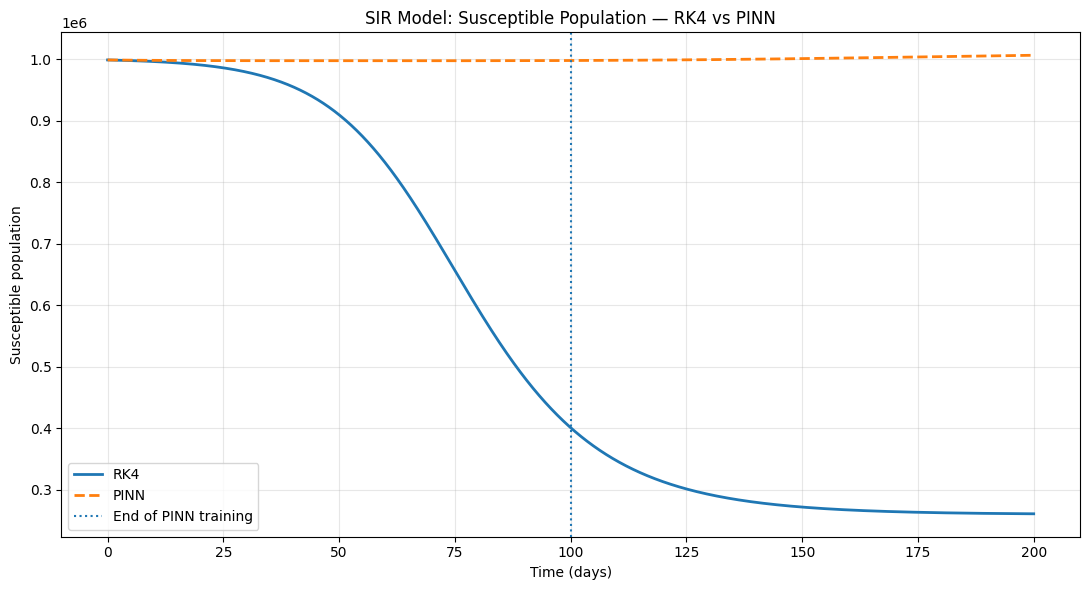

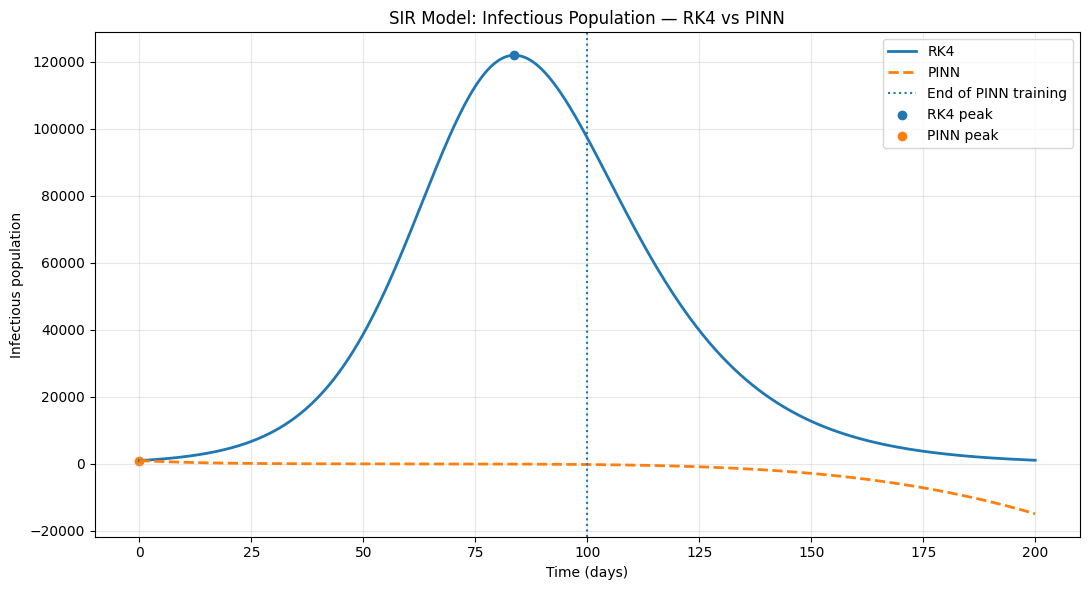

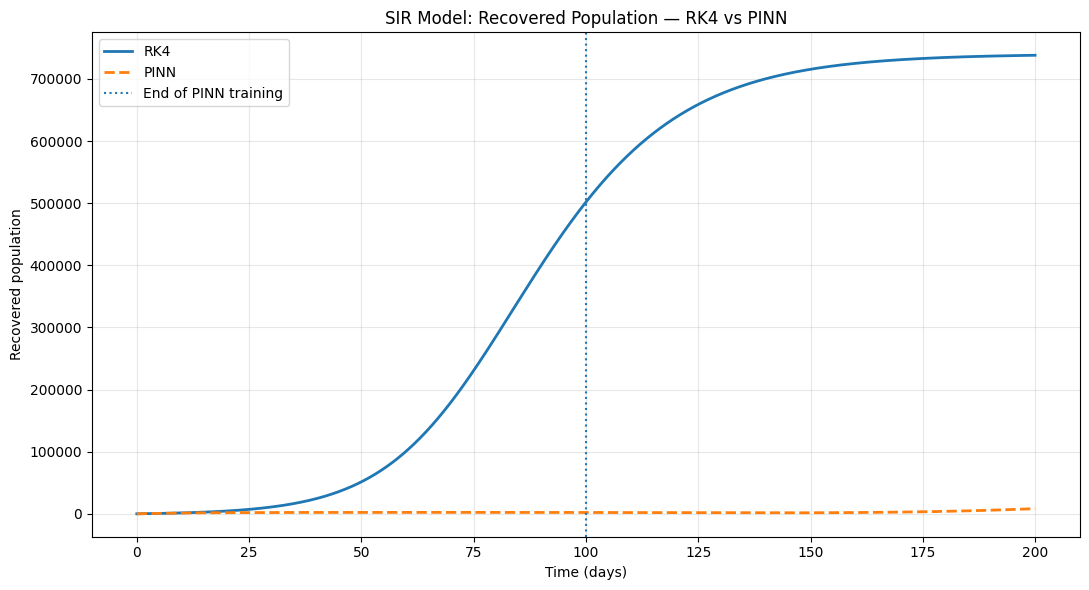

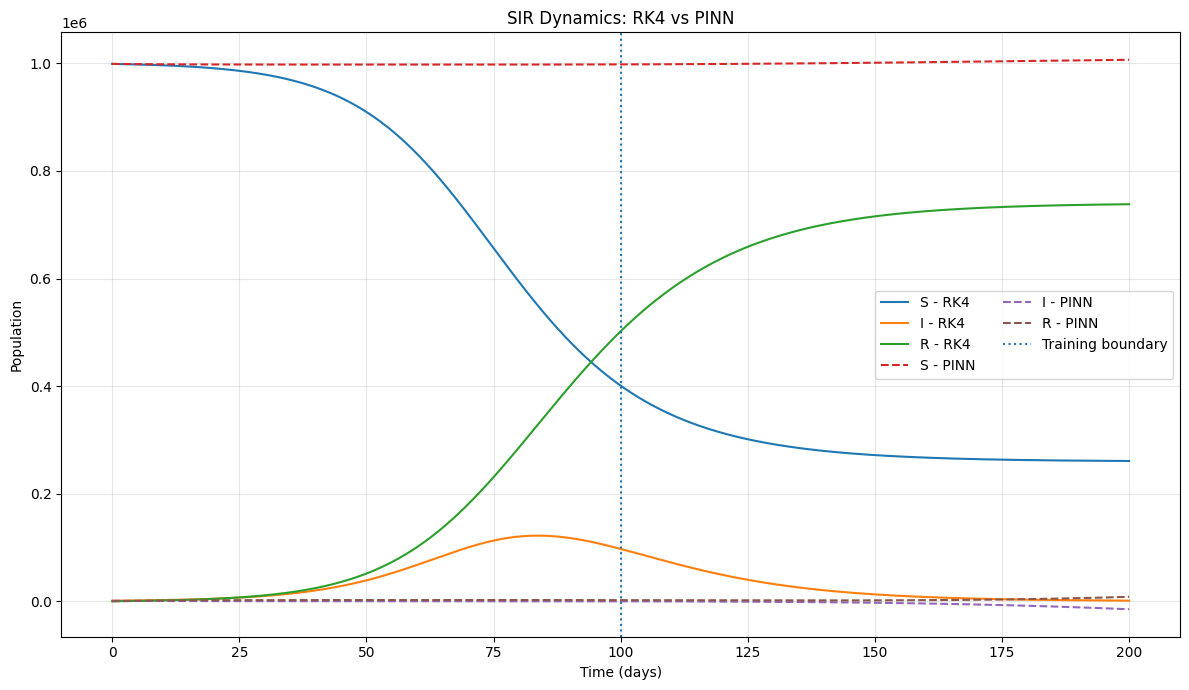

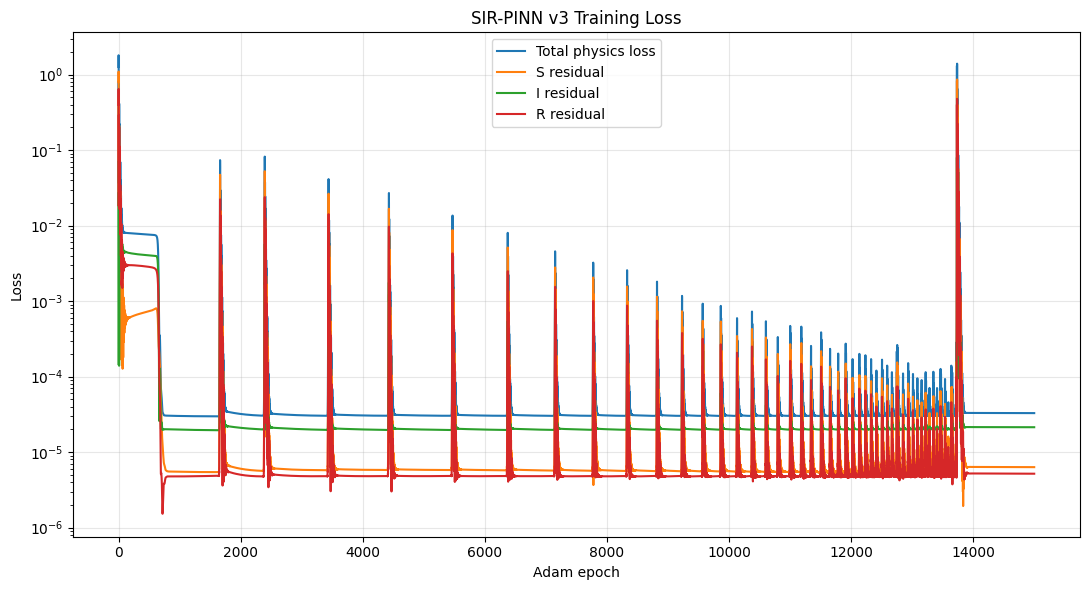

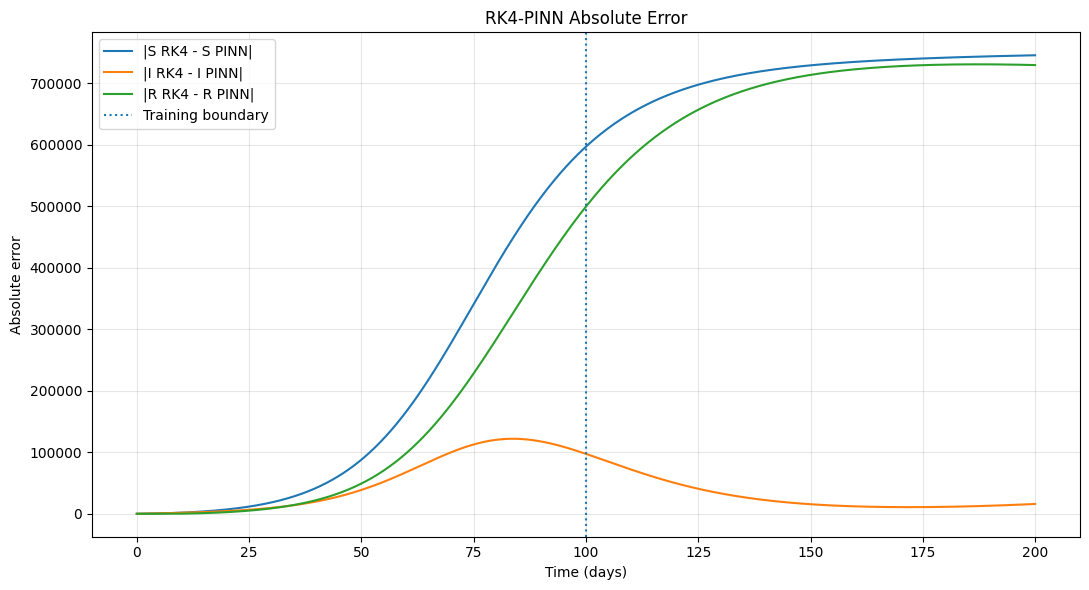

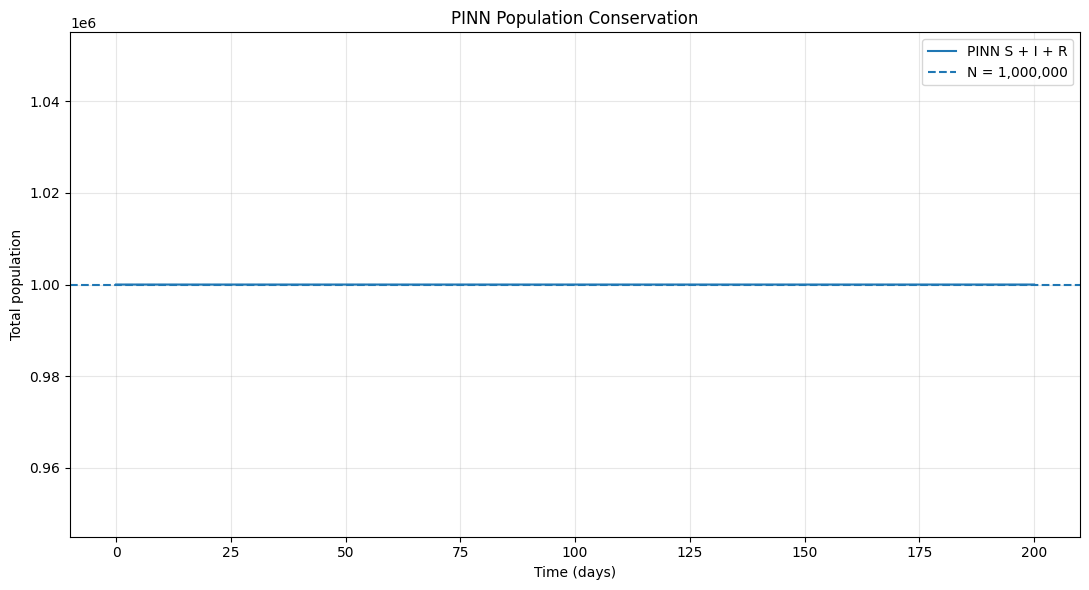



FINAL SIR-PINN v3 SUMMARY

Beta  = 0.17150948
Gamma = 0.09425424
R0    = 1.81964737

Training interval: 0.0 - 100.0 days
Evaluation interval: 0.0 - 200.0 days
Collocation points: 4011
Adam epochs: 15000


FULL 0-200 DAY METRICS

S: MAE=447316.1592, RMSE=539275.5409, R²=-2.24248951

I: MAE=41272.0396, RMSE=56838.8023, R²=-0.95790908

R: MAE=406051.2421, RMSE=505657.6991, R²=-1.80605013


PEAK INFECTION
RK4  = 122,004.3883
PINN = 1,000.0000
RK4 peak day  = 83.70
PINN peak day = 0.00

Peak value error: 99.180357%
Peak timing error: 83.70 days


CONSERVATION
Maximum PINN conservation error: 1.164153218269e-10


PHYSICS RESIDUAL
Total: 7.408525728330e-03


SIR-PINN v3 COMPLETED


In [59]:

# ============================================================
# 18. PREPARE MODEL PARAMETERS FOR L-BFGS
# ============================================================

trainable_variables = (
    model.trainable_variables
)


# Store shapes

variable_shapes = [
    v.shape
    for v in trainable_variables
]


# Number of elements

variable_sizes = [
    int(np.prod(v.shape))
    for v in trainable_variables
]


total_parameters = sum(
    variable_sizes
)


print("\n")
print("=" * 80)
print("L-BFGS PREPARATION")
print("=" * 80)

print(
    f"Total trainable parameters: "
    f"{total_parameters}"
)


# ============================================================
# 19. FLATTEN MODEL PARAMETERS
# ============================================================

def get_flat_parameters():

    flat_parameters = []

    for variable in trainable_variables:

        flat_parameters.append(
            variable.numpy().reshape(-1)
        )

    return np.concatenate(
        flat_parameters
    )


# ============================================================
# 20. SET FLAT PARAMETERS
# ============================================================

def set_flat_parameters(
    flat_parameters
):

    position = 0

    for variable, size, shape in zip(
        trainable_variables,
        variable_sizes,
        variable_shapes
    ):

        new_values = (
            flat_parameters[
                position:
                position + size
            ]
            .reshape(shape)
        )

        variable.assign(
            new_values
        )

        position += size


# ============================================================
# 21. L-BFGS LOSS + GRADIENT
# ============================================================

def lbfgs_objective(
    flat_parameters
):

    # Set parameters

    set_flat_parameters(
        flat_parameters
    )


    with tf.GradientTape() as tape:

        (
            loss,
            physics,
            loss_s,
            loss_i,
            loss_r
        ) = total_loss(
            tau_collocation
        )


    gradients = tape.gradient(
        loss,
        trainable_variables
    )


    # Flatten gradients

    flat_gradients = []

    for gradient in gradients:

        if gradient is None:

            flat_gradients.append(
                np.zeros(
                    gradient.shape
                    if gradient is not None
                    else (0,),
                    dtype=np.float64
                )
            )

        else:

            flat_gradients.append(
                gradient.numpy().reshape(-1)
            )


    flat_gradients = np.concatenate(
        flat_gradients
    )


    return (
        float(loss.numpy()),
        flat_gradients
    )


# ============================================================
# 22. RUN L-BFGS
# ============================================================

initial_parameters = (
    get_flat_parameters()
)


print("\n")
print("=" * 80)
print("PHASE 2: L-BFGS-B REFINEMENT")
print("=" * 80)

print(
    "Starting L-BFGS-B..."
)


lbfgs_result = minimize(
    fun=lbfgs_objective,
    x0=initial_parameters,
    jac=True,
    method="L-BFGS-B",
    options={
        "maxiter": 3000,
        "maxfun": 5000,
        "maxls": 50,
        "ftol": 1e-12,
        "gtol": 1e-10,
        "maxcor": 50
    }
)


# Set final parameters

set_flat_parameters(
    lbfgs_result.x
)


print("\nL-BFGS completed.")

print(
    "Success:",
    lbfgs_result.success
)

print(
    "Message:",
    lbfgs_result.message
)

print(
    "Iterations:",
    lbfgs_result.nit
)

print(
    "Function evaluations:",
    lbfgs_result.nfev
)

print(
    "Final L-BFGS loss:",
    lbfgs_result.fun
)


# ============================================================
# 23. CREATE EVALUATION GRID
# ============================================================

tau_test = (
    t_rk4
    / TIME_SCALE
).reshape(-1, 1)


tau_test_tf = tf.convert_to_tensor(
    tau_test,
    dtype=tf.float64
)


# ============================================================
# 24. PINN PREDICTION
# ============================================================

pinn_normalized = model(
    tau_test_tf
).numpy()


s_pinn = (
    pinn_normalized[:, 0]
)

i_pinn = (
    pinn_normalized[:, 1]
)

r_pinn = (
    pinn_normalized[:, 2]
)


# Convert to population values

S_pinn = (
    s_pinn * N
)

I_pinn = (
    i_pinn * N
)

R_pinn = (
    r_pinn * N
)


# ============================================================
# 25. METRIC FUNCTION
# ============================================================

def calculate_metrics(
    actual,
    predicted
):

    mae = mean_absolute_error(
        actual,
        predicted
    )

    mse = mean_squared_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mse
    )

    r2 = r2_score(
        actual,
        predicted
    )

    return (
        mae,
        mse,
        rmse,
        r2
    )


# ============================================================
# 26. CALCULATE METRICS - FULL 0-200 DAYS
# ============================================================

metrics = {}

metrics["S"] = calculate_metrics(
    S_rk4,
    S_pinn
)

metrics["I"] = calculate_metrics(
    I_rk4,
    I_pinn
)

metrics["R"] = calculate_metrics(
    R_rk4,
    R_pinn
)


# ============================================================
# 27. TRAINING-REGION METRICS: 0-100 DAYS
# ============================================================

train_mask = (
    t_rk4 <= TRAIN_END
)

S_train_metrics = calculate_metrics(
    S_rk4[train_mask],
    S_pinn[train_mask]
)

I_train_metrics = calculate_metrics(
    I_rk4[train_mask],
    I_pinn[train_mask]
)

R_train_metrics = calculate_metrics(
    R_rk4[train_mask],
    R_pinn[train_mask]
)


# ============================================================
# 28. EXTRAPOLATION METRICS: 100-200 DAYS
# ============================================================

extra_mask = (
    t_rk4 > TRAIN_END
)

S_extra_metrics = calculate_metrics(
    S_rk4[extra_mask],
    S_pinn[extra_mask]
)

I_extra_metrics = calculate_metrics(
    I_rk4[extra_mask],
    I_pinn[extra_mask]
)

R_extra_metrics = calculate_metrics(
    R_rk4[extra_mask],
    R_pinn[extra_mask]
)


# ============================================================
# 29. PRINT FULL METRICS
# ============================================================

print("\n")
print("=" * 80)
print("FULL 0-200 DAY RK4 VS PINN PERFORMANCE")
print("=" * 80)


for compartment in [
    "S",
    "I",
    "R"
]:

    mae, mse, rmse, r2 = (
        metrics[compartment]
    )

    print(
        f"\n{compartment} COMPARTMENT"
    )

    print(
        "-" * 60
    )

    print(
        f"MAE  : {mae:.6f}"
    )

    print(
        f"MSE  : {mse:.6f}"
    )

    print(
        f"RMSE : {rmse:.6f}"
    )

    print(
        f"R²   : {r2:.8f}"
    )


# ============================================================
# 30. PRINT TRAINING METRICS
# ============================================================

print("\n")
print("=" * 80)
print("TRAINING REGION: 0-100 DAYS")
print("=" * 80)


for name, values in [
    ("S", S_train_metrics),
    ("I", I_train_metrics),
    ("R", R_train_metrics)
]:

    mae, mse, rmse, r2 = values

    print(
        f"\n{name}"
    )

    print(
        f"MAE  = {mae:.6f}"
    )

    print(
        f"MSE  = {mse:.6f}"
    )

    print(
        f"RMSE = {rmse:.6f}"
    )

    print(
        f"R²   = {r2:.8f}"
    )


# ============================================================
# 31. PRINT EXTRAPOLATION METRICS
# ============================================================

print("\n")
print("=" * 80)
print("EXTRAPOLATION REGION: 100-200 DAYS")
print("=" * 80)


for name, values in [
    ("S", S_extra_metrics),
    ("I", I_extra_metrics),
    ("R", R_extra_metrics)
]:

    mae, mse, rmse, r2 = values

    print(
        f"\n{name}"
    )

    print(
        f"MAE  = {mae:.6f}"
    )

    print(
        f"MSE  = {mse:.6f}"
    )

    print(
        f"RMSE = {rmse:.6f}"
    )

    print(
        f"R²   = {r2:.8f}"
    )


# ============================================================
# 32. OVERALL METRICS
# ============================================================

all_actual = np.concatenate(
    [
        S_rk4,
        I_rk4,
        R_rk4
    ]
)

all_predicted = np.concatenate(
    [
        S_pinn,
        I_pinn,
        R_pinn
    ]
)


overall_mae = mean_absolute_error(
    all_actual,
    all_predicted
)

overall_mse = mean_squared_error(
    all_actual,
    all_predicted
)

overall_rmse = np.sqrt(
    overall_mse
)

overall_r2 = r2_score(
    all_actual,
    all_predicted
)


print("\n")
print("=" * 80)
print("OVERALL 0-200 DAY PERFORMANCE")
print("=" * 80)

print(
    f"MAE  = {overall_mae:.6f}"
)

print(
    f"MSE  = {overall_mse:.6f}"
)

print(
    f"RMSE = {overall_rmse:.6f}"
)

print(
    f"R²   = {overall_r2:.8f}"
)


# ============================================================
# 33. PEAK INFECTED - RK4
# ============================================================

rk4_peak_index = np.argmax(
    I_rk4
)

rk4_peak_value = I_rk4[
    rk4_peak_index
]

rk4_peak_time = t_rk4[
    rk4_peak_index
]


# ============================================================
# 34. PEAK INFECTED - PINN
# ============================================================

pinn_peak_index = np.argmax(
    I_pinn
)

pinn_peak_value = I_pinn[
    pinn_peak_index
]

pinn_peak_time = t_rk4[
    pinn_peak_index
]


# ============================================================
# 35. PEAK ERRORS
# ============================================================

peak_value_error_percent = (
    abs(
        pinn_peak_value
        - rk4_peak_value
    )
    / rk4_peak_value
    * 100.0
)


peak_time_error = abs(
    pinn_peak_time
    - rk4_peak_time
)


# ============================================================
# 36. PRINT PEAK RESULTS
# ============================================================

print("\n")
print("=" * 80)
print("PEAK INFECTED COMPARISON")
print("=" * 80)

print(
    f"RK4  peak I = "
    f"{rk4_peak_value:,.4f}"
)

print(
    f"PINN peak I = "
    f"{pinn_peak_value:,.4f}"
)

print(
    f"\nRK4 peak time = "
    f"{rk4_peak_time:.2f} days"
)

print(
    f"PINN peak time = "
    f"{pinn_peak_time:.2f} days"
)

print(
    f"\nPeak value error = "
    f"{peak_value_error_percent:.6f}%"
)

print(
    f"Peak timing error = "
    f"{peak_time_error:.2f} days"
)


# ============================================================
# 37. POPULATION CONSERVATION
# ============================================================

rk4_total = (
    S_rk4
    + I_rk4
    + R_rk4
)

pinn_total = (
    S_pinn
    + I_pinn
    + R_pinn
)


rk4_conservation_error = (
    np.abs(
        rk4_total - N
    )
)


pinn_conservation_error = (
    np.abs(
        pinn_total - N
    )
)


print("\n")
print("=" * 80)
print("POPULATION CONSERVATION")
print("=" * 80)

print(
    "RK4 maximum conservation error:"
)

print(
    f"{np.max(rk4_conservation_error):.12e}"
)


print(
    "\nPINN maximum conservation error:"
)

print(
    f"{np.max(pinn_conservation_error):.12e}"
)


print(
    "\nPINN mean conservation error:"
)

print(
    f"{np.mean(pinn_conservation_error):.12e}"
)


# ============================================================
# 38. PHYSICS RESIDUAL ON 0-200 DAYS
# ============================================================

(
    physics_test,
    residual_s,
    residual_i,
    residual_r
) = physics_loss(
    tau_test_tf
)


print("\n")
print("=" * 80)
print("PHYSICS RESIDUAL - 0-200 DAYS")
print("=" * 80)

print(
    f"Total physics residual:"
    f" {physics_test.numpy():.12e}"
)

print(
    f"S residual:"
    f" {residual_s.numpy():.12e}"
)

print(
    f"I residual:"
    f" {residual_i.numpy():.12e}"
)

print(
    f"R residual:"
    f" {residual_r.numpy():.12e}"
)


# ============================================================
# 39. CHECK INITIAL CONDITION
# ============================================================

initial_prediction = (
    model(
        tf.constant(
            [[0.0]],
            dtype=tf.float64
        )
    ).numpy()[0]
)


print("\n")
print("=" * 80)
print("INITIAL CONDITION CHECK")
print("=" * 80)

print(
    f"True s(0) = {s0:.12f}"
)

print(
    f"PINN s(0) = "
    f"{initial_prediction[0]:.12f}"
)

print(
    f"\nTrue i(0) = {i0:.12f}"
)

print(
    f"PINN i(0) = "
    f"{initial_prediction[1]:.12f}"
)

print(
    f"\nTrue r(0) = {r0:.12f}"
)

print(
    f"PINN r(0) = "
    f"{initial_prediction[2]:.12f}"
)


# ============================================================
# 40. CREATE RESULTS DATAFRAME
# ============================================================

results_df = pd.DataFrame({

    "Time": t_rk4,

    "S_RK4": S_rk4,

    "I_RK4": I_rk4,

    "R_RK4": R_rk4,

    "S_PINN": S_pinn,

    "I_PINN": I_pinn,

    "R_PINN": R_pinn,

    "RK4_Total": rk4_total,

    "PINN_Total": pinn_total,

    "PINN_Conservation_Error":
        pinn_conservation_error

})


# ============================================================
# 41. SAVE RESULTS
# ============================================================

results_df.to_csv(
    "sir_pinn_v3_results.csv",
    index=False
)


print(
    "\nResults saved:"
    " sir_pinn_v3_results.csv"
)


# ============================================================
# 42. METRICS DATAFRAME
# ============================================================

metrics_df = pd.DataFrame({

    "Compartment": [
        "S",
        "I",
        "R"
    ],

    "MAE": [
        metrics["S"][0],
        metrics["I"][0],
        metrics["R"][0]
    ],

    "MSE": [
        metrics["S"][1],
        metrics["I"][1],
        metrics["R"][1]
    ],

    "RMSE": [
        metrics["S"][2],
        metrics["I"][2],
        metrics["R"][2]
    ],

    "R2": [
        metrics["S"][3],
        metrics["I"][3],
        metrics["R"][3]
    ]

})


metrics_df.to_csv(
    "sir_pinn_v3_metrics.csv",
    index=False
)


print(
    "Metrics saved:"
    " sir_pinn_v3_metrics.csv"
)


# ============================================================
# 43. TRAINING/EXTRAPOLATION METRICS DATAFRAME
# ============================================================

region_metrics_df = pd.DataFrame({

    "Region": [
        "Training_0_100",
        "Training_0_100",
        "Training_0_100",
        "Extrapolation_100_200",
        "Extrapolation_100_200",
        "Extrapolation_100_200"
    ],

    "Compartment": [
        "S",
        "I",
        "R",
        "S",
        "I",
        "R"
    ],

    "MAE": [
        S_train_metrics[0],
        I_train_metrics[0],
        R_train_metrics[0],
        S_extra_metrics[0],
        I_extra_metrics[0],
        R_extra_metrics[0]
    ],

    "MSE": [
        S_train_metrics[1],
        I_train_metrics[1],
        R_train_metrics[1],
        S_extra_metrics[1],
        I_extra_metrics[1],
        R_extra_metrics[1]
    ],

    "RMSE": [
        S_train_metrics[2],
        I_train_metrics[2],
        R_train_metrics[2],
        S_extra_metrics[2],
        I_extra_metrics[2],
        R_extra_metrics[2]
    ],

    "R2": [
        S_train_metrics[3],
        I_train_metrics[3],
        R_train_metrics[3],
        S_extra_metrics[3],
        I_extra_metrics[3],
        R_extra_metrics[3]
    ]

})


region_metrics_df.to_csv(
    "sir_pinn_v3_region_metrics.csv",
    index=False
)


print(
    "Region metrics saved:"
    " sir_pinn_v3_region_metrics.csv"
)


# ============================================================
# 44. SAVE MODEL WEIGHTS
# ============================================================

model.save_weights(
    "sir_pinn_v3.weights.h5"
)


print(
    "Model weights saved:"
    " sir_pinn_v3.weights.h5"
)


# ============================================================
# 45. PLOT 1 - S
# ============================================================

plt.figure(
    figsize=(11, 6)
)

plt.plot(
    t_rk4,
    S_rk4,
    label="RK4",
    linewidth=2
)

plt.plot(
    t_rk4,
    S_pinn,
    "--",
    label="PINN",
    linewidth=2
)

plt.axvline(
    TRAIN_END,
    linestyle=":",
    linewidth=1.5,
    label="End of PINN training"
)

plt.xlabel(
    "Time (days)"
)

plt.ylabel(
    "Susceptible population"
)

plt.title(
    "SIR Model: Susceptible Population — RK4 vs PINN"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 46. PLOT 2 - I
# ============================================================

plt.figure(
    figsize=(11, 6)
)

plt.plot(
    t_rk4,
    I_rk4,
    label="RK4",
    linewidth=2
)

plt.plot(
    t_rk4,
    I_pinn,
    "--",
    label="PINN",
    linewidth=2
)

plt.axvline(
    TRAIN_END,
    linestyle=":",
    linewidth=1.5,
    label="End of PINN training"
)

plt.scatter(
    [rk4_peak_time],
    [rk4_peak_value],
    label="RK4 peak"
)

plt.scatter(
    [pinn_peak_time],
    [pinn_peak_value],
    label="PINN peak"
)

plt.xlabel(
    "Time (days)"
)

plt.ylabel(
    "Infectious population"
)

plt.title(
    "SIR Model: Infectious Population — RK4 vs PINN"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 47. PLOT 3 - R
# ============================================================

plt.figure(
    figsize=(11, 6)
)

plt.plot(
    t_rk4,
    R_rk4,
    label="RK4",
    linewidth=2
)

plt.plot(
    t_rk4,
    R_pinn,
    "--",
    label="PINN",
    linewidth=2
)

plt.axvline(
    TRAIN_END,
    linestyle=":",
    linewidth=1.5,
    label="End of PINN training"
)

plt.xlabel(
    "Time (days)"
)

plt.ylabel(
    "Recovered population"
)

plt.title(
    "SIR Model: Recovered Population — RK4 vs PINN"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 48. PLOT 4 - ALL COMPARTMENTS
# ============================================================

plt.figure(
    figsize=(12, 7)
)

plt.plot(
    t_rk4,
    S_rk4,
    label="S - RK4"
)

plt.plot(
    t_rk4,
    I_rk4,
    label="I - RK4"
)

plt.plot(
    t_rk4,
    R_rk4,
    label="R - RK4"
)

plt.plot(
    t_rk4,
    S_pinn,
    "--",
    label="S - PINN"
)

plt.plot(
    t_rk4,
    I_pinn,
    "--",
    label="I - PINN"
)

plt.plot(
    t_rk4,
    R_pinn,
    "--",
    label="R - PINN"
)

plt.axvline(
    TRAIN_END,
    linestyle=":",
    linewidth=1.5,
    label="Training boundary"
)

plt.xlabel(
    "Time (days)"
)

plt.ylabel(
    "Population"
)

plt.title(
    "SIR Dynamics: RK4 vs PINN"
)

plt.legend(
    ncol=2
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 49. PLOT 5 - TRAINING LOSS
# ============================================================

plt.figure(
    figsize=(11, 6)
)

plt.semilogy(
    loss_history,
    label="Total physics loss"
)

plt.semilogy(
    loss_s_history,
    label="S residual"
)

plt.semilogy(
    loss_i_history,
    label="I residual"
)

plt.semilogy(
    loss_r_history,
    label="R residual"
)

plt.xlabel(
    "Adam epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "SIR-PINN v3 Training Loss"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 50. PLOT 6 - PINN ERROR
# ============================================================

S_error = np.abs(
    S_rk4 - S_pinn
)

I_error = np.abs(
    I_rk4 - I_pinn
)

R_error = np.abs(
    R_rk4 - R_pinn
)


plt.figure(
    figsize=(11, 6)
)

plt.plot(
    t_rk4,
    S_error,
    label="|S RK4 - S PINN|"
)

plt.plot(
    t_rk4,
    I_error,
    label="|I RK4 - I PINN|"
)

plt.plot(
    t_rk4,
    R_error,
    label="|R RK4 - R PINN|"
)

plt.axvline(
    TRAIN_END,
    linestyle=":",
    linewidth=1.5,
    label="Training boundary"
)

plt.xlabel(
    "Time (days)"
)

plt.ylabel(
    "Absolute error"
)

plt.title(
    "RK4-PINN Absolute Error"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 51. PLOT 7 - CONSERVATION
# ============================================================

plt.figure(
    figsize=(11, 6)
)

plt.plot(
    t_rk4,
    pinn_total,
    label="PINN S + I + R"
)

plt.axhline(
    N,
    linestyle="--",
    label="N = 1,000,000"
)

plt.xlabel(
    "Time (days)"
)

plt.ylabel(
    "Total population"
)

plt.title(
    "PINN Population Conservation"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 52. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 80)
print("FINAL SIR-PINN v3 SUMMARY")
print("=" * 80)

print(
    f"\nBeta  = {BETA}"
)

print(
    f"Gamma = {GAMMA}"
)

print(
    f"R0    = {R_BASIC:.8f}"
)

print(
    f"\nTraining interval:"
    f" {TRAIN_START} - {TRAIN_END} days"
)

print(
    f"Evaluation interval:"
    f" {TEST_START} - {TEST_END} days"
)

print(
    f"Collocation points:"
    f" {len(t_collocation)}"
)

print(
    f"Adam epochs:"
    f" {ADAM_EPOCHS}"
)

print("\n")
print("FULL 0-200 DAY METRICS")

print(
    f"\nS: "
    f"MAE={metrics['S'][0]:.4f}, "
    f"RMSE={metrics['S'][2]:.4f}, "
    f"R²={metrics['S'][3]:.8f}"
)

print(
    f"\nI: "
    f"MAE={metrics['I'][0]:.4f}, "
    f"RMSE={metrics['I'][2]:.4f}, "
    f"R²={metrics['I'][3]:.8f}"
)

print(
    f"\nR: "
    f"MAE={metrics['R'][0]:.4f}, "
    f"RMSE={metrics['R'][2]:.4f}, "
    f"R²={metrics['R'][3]:.8f}"
)


print("\n")
print("PEAK INFECTION")

print(
    f"RK4  = {rk4_peak_value:,.4f}"
)

print(
    f"PINN = {pinn_peak_value:,.4f}"
)

print(
    f"RK4 peak day  = "
    f"{rk4_peak_time:.2f}"
)

print(
    f"PINN peak day = "
    f"{pinn_peak_time:.2f}"
)

print(
    f"\nPeak value error:"
    f" {peak_value_error_percent:.6f}%"
)

print(
    f"Peak timing error:"
    f" {peak_time_error:.2f} days"
)


print("\n")
print("CONSERVATION")

print(
    f"Maximum PINN conservation error:"
    f" {np.max(pinn_conservation_error):.12e}"
)


print("\n")
print("PHYSICS RESIDUAL")

print(
    f"Total:"
    f" {physics_test.numpy():.12e}"
)


print("\n")
print("=" * 80)
print("SIR-PINN v3 COMPLETED")
print("=" * 80)

***
### References
[^1]: Pant B, Levine ME, Nande A, Garcia RG, Dewey G, Link NB, Santillana M. Resolving parameter uncertainty in SIR models through population-level serological surveillance: A synthetic study. *Infect Dis Model*. 2026;11(4):1491-1503. doi:10.1016/j.idm.2026.05.004
<br>[^2] Tuncer N, Le TT. Structural and practical identifiability analysis of outbreak models. Math Biosci. 2018 May;299:1-18. doi: 10.1016/j.mbs.2018.02.004. Epub 2018 Mar 29. PMID: 29477671.